In [ ]:
#FEATURE SCALING

In [225]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE, ADASYN, KMeansSMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss, ClusterCentroids
from imblearn.combine import SMOTEENN

# Load the dataset
df = pd.read_csv(r"T:\00 445\student\student-mat.csv", sep=";")

# Create binary target variable: 1 = Pass (G3 ≥ 10), 0 = Fail
df['pass'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)


#df.drop(columns=['G2','Medu','Fedu','studytime','famrel', 'G3'], inplace=True)
#df.drop(columns=['G2','G1', 'G3'], inplace=True)
#df.drop(columns=['G1','G2','Medu','Fedu','studytime','famrel', 'G3'], inplace=True)
#df.drop(columns=['G2','G3'], inplace=True)
#df.drop(columns=['G3'], inplace=True)

# Separate features and target
X = df.drop(columns=['pass'])
y = df['pass']

# One-Hot Encoding for categorical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()
column_transformer = ColumnTransformer([("onehot", OneHotEncoder(drop='first'), categorical_cols)], remainder='passthrough')

# Transform the dataset
X_encoded = column_transformer.fit_transform(X)

# Convert the transformed data back to DataFrame
X_df = pd.DataFrame(X_encoded.toarray() if hasattr(X_encoded, 'toarray') else X_encoded)

# Split the dataset: 80% train, 5% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X_df, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.55, stratify=y_temp, random_state=42)


# Flag to choose the sampling technique
SAMPLING_TECHNIQUE = 'ADASYN'
  # Options: 'SMOTE', 'ADASYN', 'SMOTEENN', 'UnderSampling', 'TomekLinks', 'NearMiss', 'ClusterCentroids', 'KMeansSMOTE'

# Apply selected sampling technique
if SAMPLING_TECHNIQUE == 'SMOTE':
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
    print("After SMOTE:")
    print(pd.Series(y_train_bal).value_counts())
elif SAMPLING_TECHNIQUE == 'ADASYN':
    adasyn = ADASYN(random_state=42)
    X_train_bal, y_train_bal = adasyn.fit_resample(X_train, y_train)
    print("After ADASYN:")
    print(pd.Series(y_train_bal).value_counts())
elif SAMPLING_TECHNIQUE == 'SMOTEENN':
    smote_enn = SMOTEENN(random_state=42)
    X_train_bal, y_train_bal = smote_enn.fit_resample(X_train, y_train)
    print("After SMOTEENN:")
    print(pd.Series(y_train_bal).value_counts())
elif SAMPLING_TECHNIQUE == 'UnderSampling':
    undersampler = RandomUnderSampler(random_state=42)
    X_train_bal, y_train_bal = undersampler.fit_resample(X_train, y_train)
    print("After Under-sampling:")
    print(pd.Series(y_train_bal).value_counts())
elif SAMPLING_TECHNIQUE == 'TomekLinks':
    tomek = TomekLinks()
    X_train_bal, y_train_bal = tomek.fit_resample(X_train, y_train)
    print("After Tomek Links:")
    print(pd.Series(y_train_bal).value_counts())
elif SAMPLING_TECHNIQUE == 'NearMiss':
    near_miss = NearMiss(version=1)  # Use version 1, 2, or 3
    X_train_bal, y_train_bal = near_miss.fit_resample(X_train, y_train)
    print("After NearMiss:")
    print(pd.Series(y_train_bal).value_counts())
elif SAMPLING_TECHNIQUE == 'ClusterCentroids':
    cluster_centroids = ClusterCentroids(random_state=42)
    X_train_bal, y_train_bal = cluster_centroids.fit_resample(X_train, y_train)
    print("After Cluster Centroids:")
    print(pd.Series(y_train_bal).value_counts())
elif SAMPLING_TECHNIQUE == 'KMeansSMOTE':
    kmeans_smote = KMeansSMOTE(random_state=42)
    X_train_bal, y_train_bal = kmeans_smote.fit_resample(X_train, y_train)
    print("After KMeansSMOTE:")
    print(pd.Series(y_train_bal).value_counts())
else:
    # If no sampling technique is selected, use the original training data
    X_train_bal, y_train_bal = X_train, y_train

# Standardize features for training, validation, and test sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# You can now proceed with model training (e.g., Decision Tree, Random Forest, etc.)


After ADASYN:
pass
1    185
0    183
Name: count, dtype: int64


In [ ]:
#CORELATION

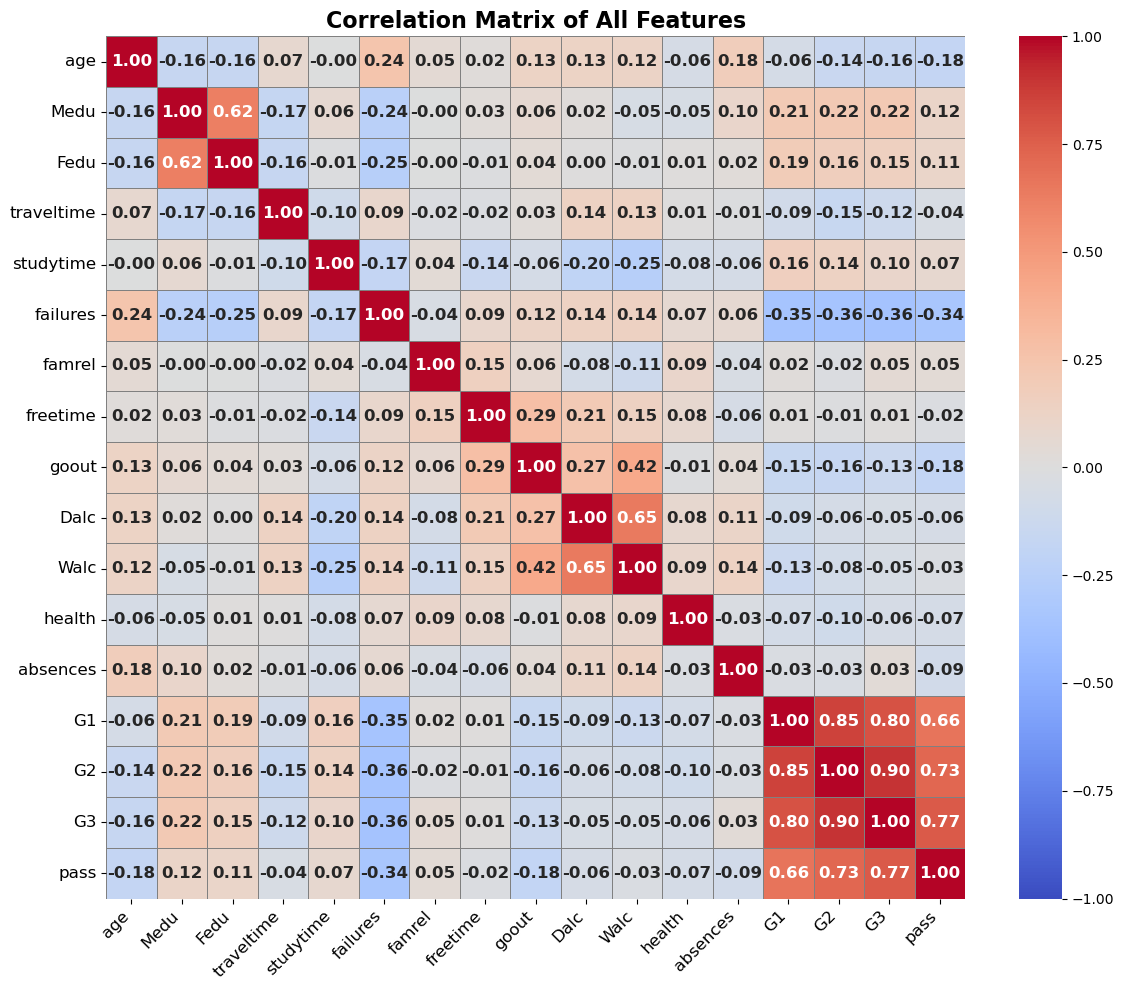

Correlation matrix of all features:
                 age      Medu      Fedu  traveltime  studytime  failures  \
age         1.000000 -0.163658 -0.163438    0.070641  -0.004140  0.243665   
Medu       -0.163658  1.000000  0.623455   -0.171639   0.064944 -0.236680   
Fedu       -0.163438  0.623455  1.000000   -0.158194  -0.009175 -0.250408   
traveltime  0.070641 -0.171639 -0.158194    1.000000  -0.100909  0.092239   
studytime  -0.004140  0.064944 -0.009175   -0.100909   1.000000 -0.173563   
failures    0.243665 -0.236680 -0.250408    0.092239  -0.173563  1.000000   
famrel      0.053940 -0.003914 -0.001370   -0.016808   0.039731 -0.044337   
freetime    0.016434  0.030891 -0.012846   -0.017025  -0.143198  0.091987   
goout       0.126964  0.064094  0.043105    0.028540  -0.063904  0.124561   
Dalc        0.131125  0.019834  0.002386    0.138325  -0.196019  0.136047   
Walc        0.117276 -0.047123 -0.012631    0.134116  -0.253785  0.141962   
health     -0.062187 -0.046878  0.014742

In [226]:
# Step 1: Select only numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate the correlation matrix for all numerical columns
correlation_matrix_all = df[numerical_cols].corr()

# Step 2: Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))  # Increase figure size for better readability
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, annot_kws={'size': 12, 'weight': 'bold'}, 
            linewidths=0.5, linecolor='gray', vmin=-1, vmax=1)  # Added grid lines and color scale range
plt.title("Correlation Matrix of All Features", fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)  # Rotate x-axis labels for better visibility
plt.yticks(rotation=0, ha='right', fontsize=12)  # Keep y-axis labels horizontal for clarity
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

# Step 3: Print the full correlation matrix
print("Correlation matrix of all features:")
print(correlation_matrix_all)


In [ ]:
#DECISION TREE

Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.69      0.58      0.63        19
           1       0.81      0.88      0.84        40

    accuracy                           0.78        59
   macro avg       0.75      0.73      0.74        59
weighted avg       0.77      0.78      0.77        59


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.62      0.75      0.68        20
           1       0.86      0.78      0.82        40

    accuracy                           0.77        60
   macro avg       0.74      0.76      0.75        60
weighted avg       0.78      0.77      0.77        60


Accuracy Comparison:
Validation Accuracy: 0.7797
Test Accuracy: 0.7667


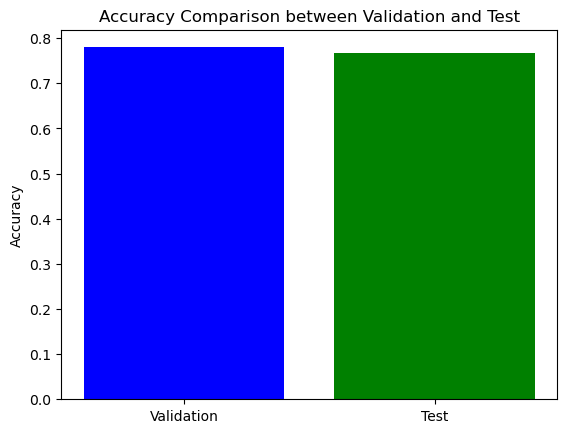

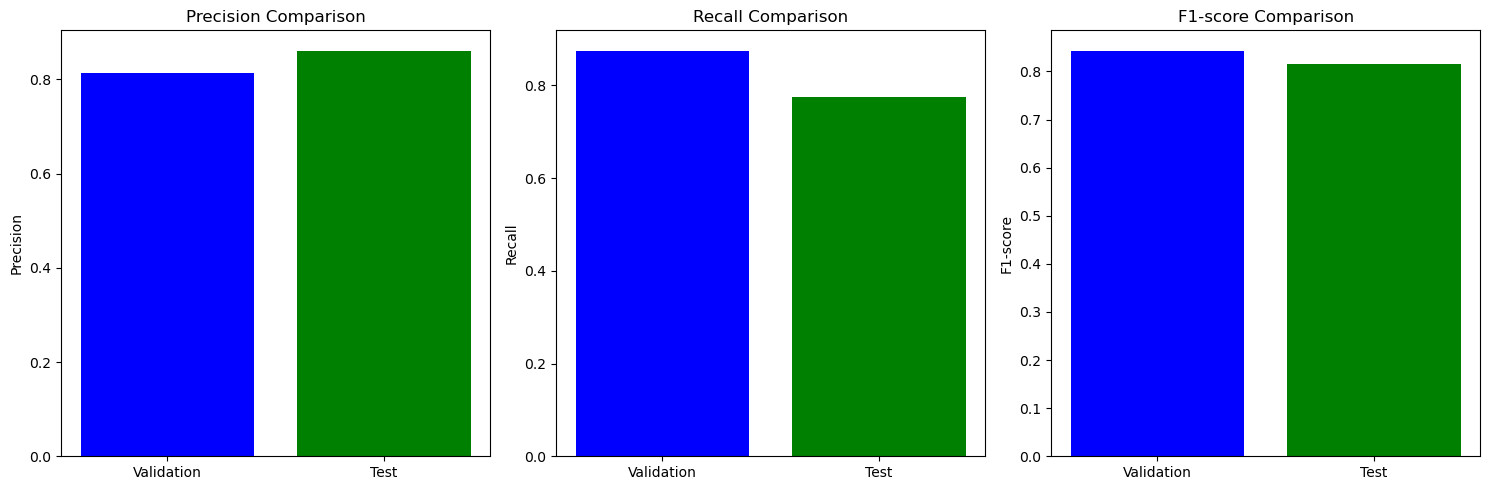

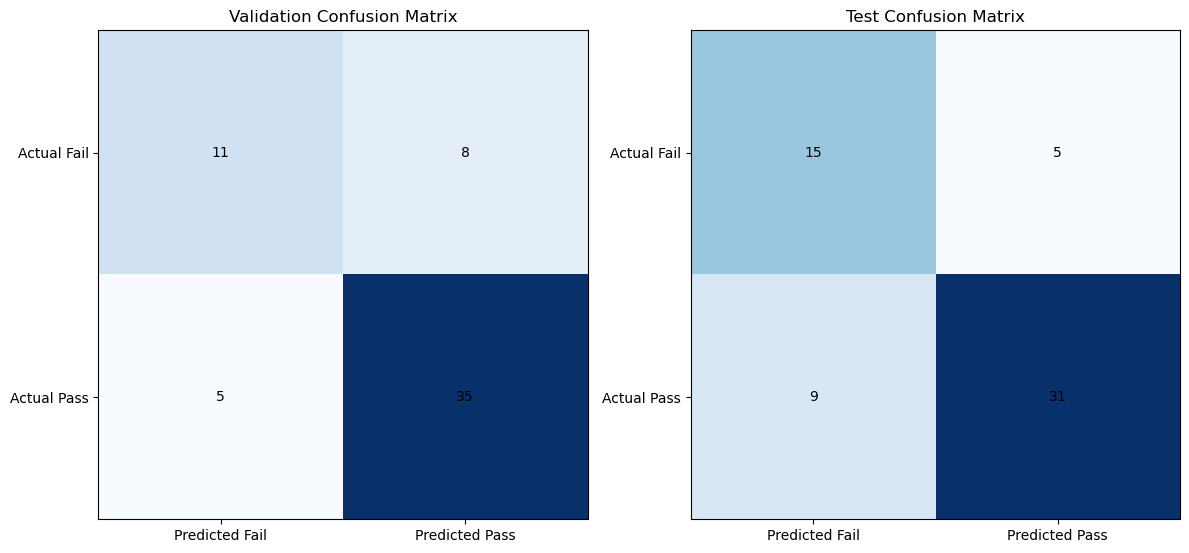

In [189]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Initialize Decision Tree Classifier with default settings
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on the balanced, scaled training data
dt_model.fit(X_train_scaled, y_train_bal)

# Predictions on validation and test sets
y_val_pred = dt_model.predict(X_val_scaled)
y_test_pred = dt_model.predict(X_test_scaled)

# Calculate classification metrics
val_report = classification_report(y_val, y_val_pred, output_dict=True)
test_report = classification_report(y_test, y_test_pred, output_dict=True)

# Accuracy comparison
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Confusion matrices
val_conf_matrix = confusion_matrix(y_val, y_val_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)

# Display classification reports as text
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# Display accuracy for validation and test sets
print("\nAccuracy Comparison:")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plotting accuracy comparison between validation and test sets
fig, ax = plt.subplots()
ax.bar(['Validation', 'Test'], [val_accuracy, test_accuracy], color=['blue', 'green'])
ax.set_title('Accuracy Comparison between Validation and Test')
ax.set_ylabel('Accuracy')
plt.show()

# Plotting other metrics comparison: precision, recall, and F1-score
metrics = ['precision', 'recall', 'f1-score']
metrics_values = {metric: [val_report['1'][metric], test_report['1'][metric]] for metric in metrics}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(metrics):
    ax[i].bar(['Validation', 'Test'], metrics_values[metric], color=['blue', 'green'])
    ax[i].set_title(f'{metric.capitalize()} Comparison')
    ax[i].set_ylabel(metric.capitalize())
plt.tight_layout()
plt.show()

# Plotting confusion matrix for better comparison with annotations
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# For Validation Confusion Matrix
ax[0].imshow(val_conf_matrix, cmap='Blues', interpolation='nearest')
ax[0].set_title('Validation Confusion Matrix')
for i in range(val_conf_matrix.shape[0]):
    for j in range(val_conf_matrix.shape[1]):
        ax[0].text(j, i, str(val_conf_matrix[i, j]), ha='center', va='center', color='black')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[0].set_yticklabels(['Actual Fail', 'Actual Pass'])

# For Test Confusion Matrix
ax[1].imshow(test_conf_matrix, cmap='Blues', interpolation='nearest')
ax[1].set_title('Test Confusion Matrix')
for i in range(test_conf_matrix.shape[0]):
    for j in range(test_conf_matrix.shape[1]):
        ax[1].text(j, i, str(test_conf_matrix[i, j]), ha='center', va='center', color='black')
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[1].set_yticklabels(['Actual Fail', 'Actual Pass'])

plt.tight_layout()
plt.show()


Best Parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


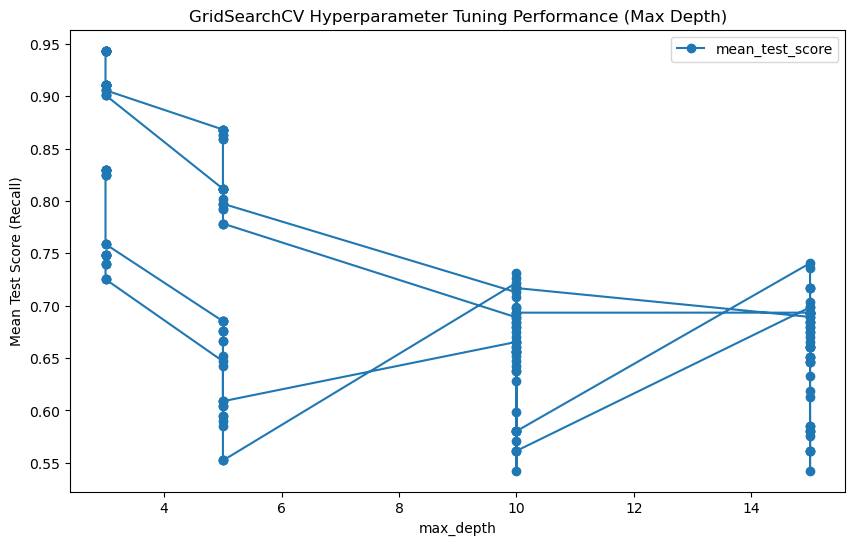

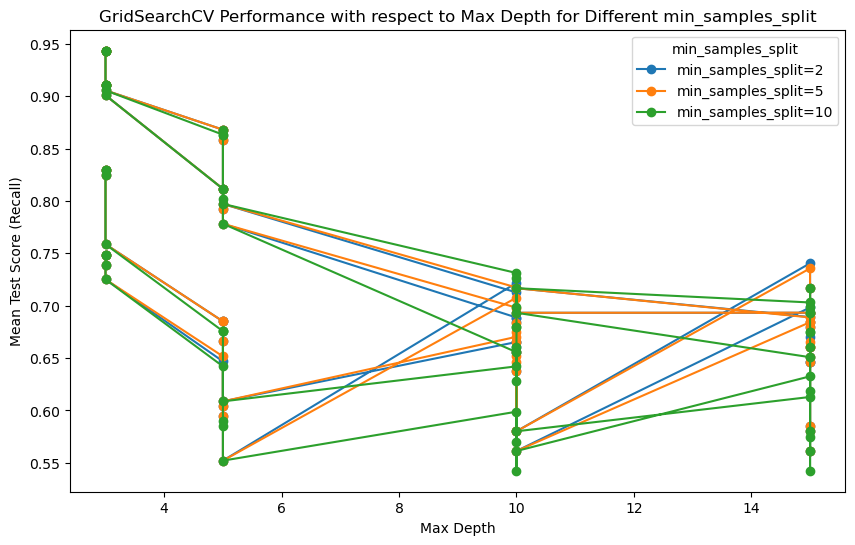

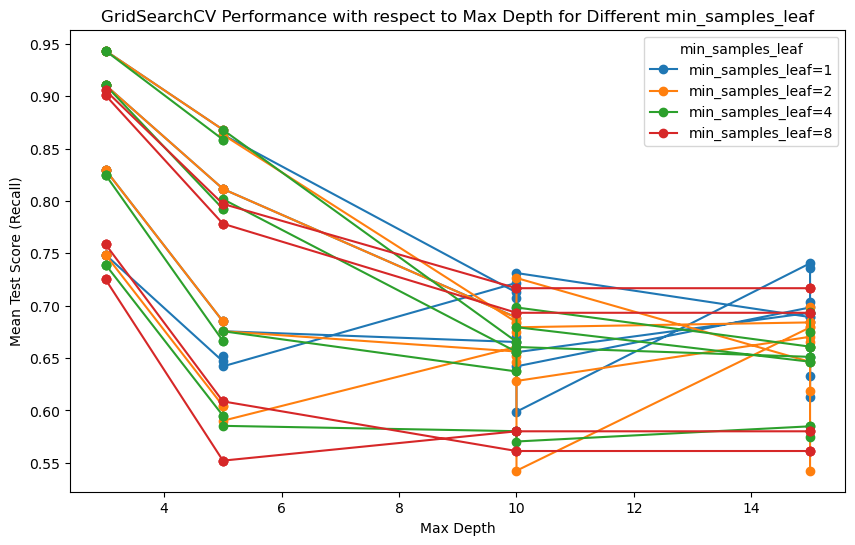

In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Initialize DecisionTreeClassifier with class_weight='balanced' for class imbalance handling
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Updated parameter grid to align with previous suggestions
param_grid_dt = {
    "criterion": ["gini", "entropy"],  # Removed 'log_loss' as it's not commonly used in Decision Trees
    "max_depth": [3, 5, 10, 15, None],  # Avoid overfitting by restricting tree depth, but leave None for no limit
    "min_samples_split": [2, 5, 10],  # Adjust based on your data size
    "min_samples_leaf": [1, 2, 4, 8],  # Try different leaf sizes to avoid overfitting
    "class_weight": ['balanced', None]  # Use 'balanced' to adjust for the class imbalance, or leave it as None
}

# Initialize GridSearchCV with 5-fold cross-validation and recall as scoring metric
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid_dt, cv=5, n_jobs=-1, scoring='recall')

# Fit GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train_bal)

# Best parameters from grid search
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Best model from grid search
best_dt_model = grid_search.best_estimator_

# Plotting grid search results: Hyperparameter tuning performance visualization for max_depth
results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 6))
plt.plot(results['param_max_depth'], results['mean_test_score'], label='mean_test_score', marker='o')
plt.title("GridSearchCV Hyperparameter Tuning Performance (Max Depth)")
plt.xlabel('max_depth')
plt.ylabel('Mean Test Score (Recall)')
plt.legend()
plt.show()

# Plot for min_samples_split
plt.figure(figsize=(10, 6))
for min_samples_split in results['param_min_samples_split'].unique():
    subset = results[results['param_min_samples_split'] == min_samples_split]
    plt.plot(subset['param_max_depth'], subset['mean_test_score'], label=f'min_samples_split={min_samples_split}', marker='o')
plt.title('GridSearchCV Performance with respect to Max Depth for Different min_samples_split')
plt.xlabel('Max Depth')
plt.ylabel('Mean Test Score (Recall)')
plt.legend(title='min_samples_split')
plt.show()

# Plot for min_samples_leaf
plt.figure(figsize=(10, 6))
for min_samples_leaf in results['param_min_samples_leaf'].unique():
    subset = results[results['param_min_samples_leaf'] == min_samples_leaf]
    plt.plot(subset['param_max_depth'], subset['mean_test_score'], label=f'min_samples_leaf={min_samples_leaf}', marker='o')
plt.title('GridSearchCV Performance with respect to Max Depth for Different min_samples_leaf')
plt.xlabel('Max Depth')
plt.ylabel('Mean Test Score (Recall)')
plt.legend(title='min_samples_leaf')
plt.show()


Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.58      0.58      0.58        19
           1       0.80      0.80      0.80        40

    accuracy                           0.73        59
   macro avg       0.69      0.69      0.69        59
weighted avg       0.73      0.73      0.73        59


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.62      0.65      0.63        20
           1       0.82      0.80      0.81        40

    accuracy                           0.75        60
   macro avg       0.72      0.73      0.72        60
weighted avg       0.75      0.75      0.75        60


Accuracy Comparison:
Validation Accuracy: 0.7288
Test Accuracy: 0.7500


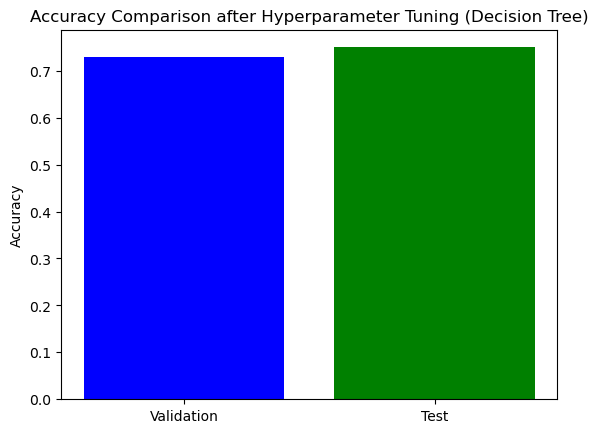

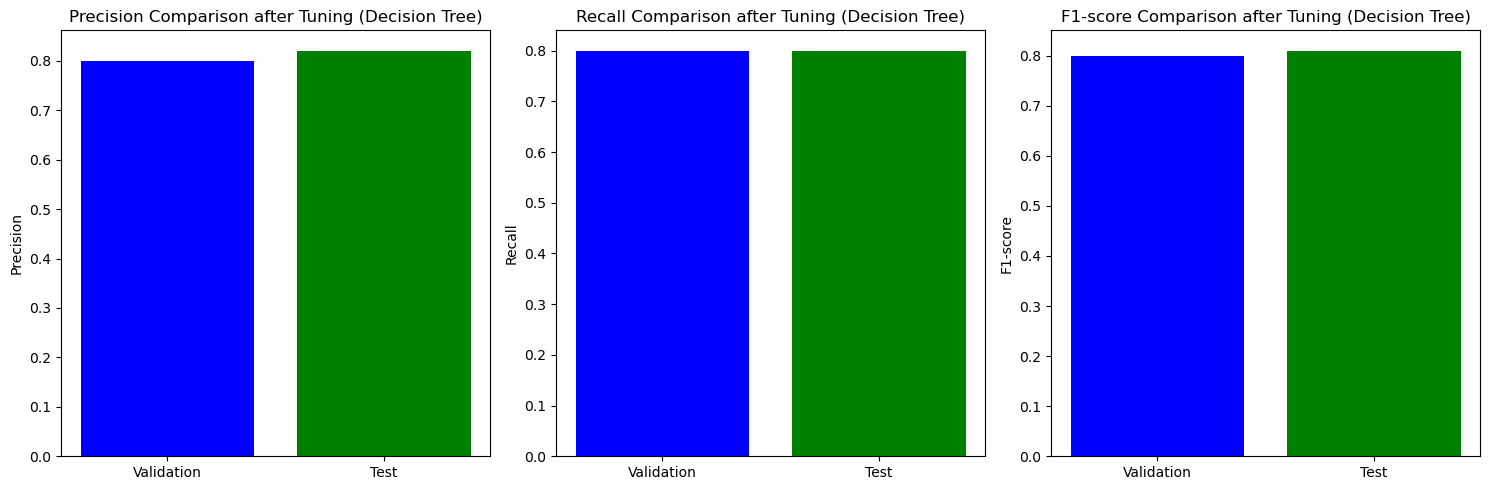

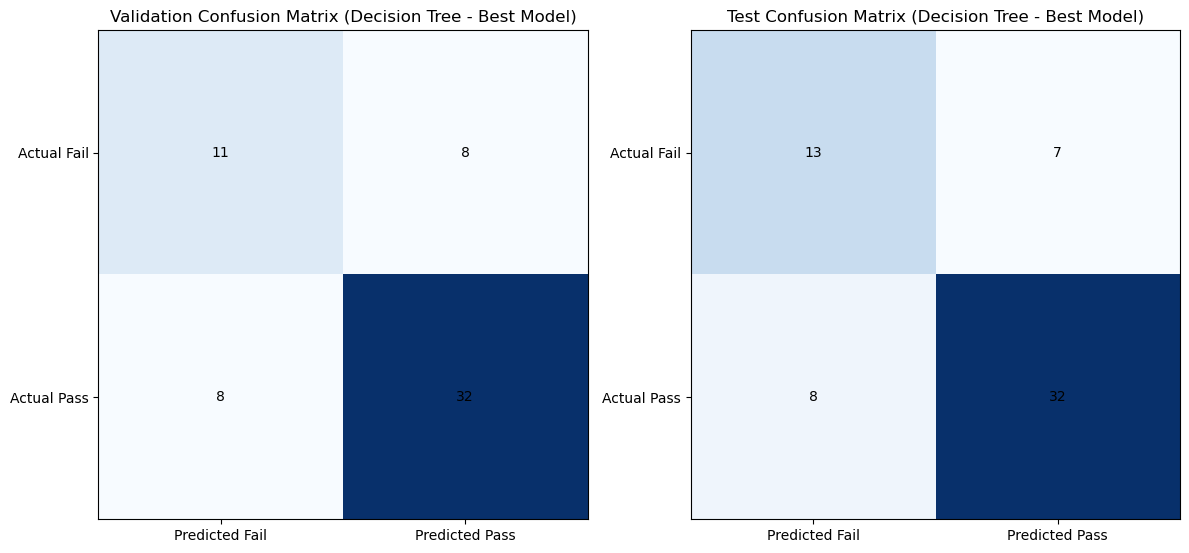

In [190]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

# Best Parameters for Decision Tree
best_dt_params = {
    'class_weight': None, 
    'criterion': 'entropy', 
    'max_depth': 13, 
    'min_samples_leaf': 1, 
    'min_samples_split': 3
}

# Initialize Decision Tree Classifier with the best hyperparameters
best_dt_model = DecisionTreeClassifier(**best_dt_params, random_state=42)

# Train the model on the balanced, scaled training data
best_dt_model.fit(X_train_scaled, y_train_bal)

# Predictions on validation and test sets with the best model
y_val_pred_dt_best = best_dt_model.predict(X_val_scaled)
y_test_pred_dt_best = best_dt_model.predict(X_test_scaled)

# Classification metrics for the tuned model
val_report_dt_best = classification_report(y_val, y_val_pred_dt_best, output_dict=True)
test_report_dt_best = classification_report(y_test, y_test_pred_dt_best, output_dict=True)

# Accuracy comparison after hyperparameter tuning
val_accuracy_dt_best = accuracy_score(y_val, y_val_pred_dt_best)
test_accuracy_dt_best = accuracy_score(y_test, y_test_pred_dt_best)

# Print the classification report for validation set in the requested format
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_dt_best))

# Print the classification report for test set in the requested format
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_dt_best))

# Display accuracy for validation and test sets
print("\nAccuracy Comparison:")
print(f"Validation Accuracy: {val_accuracy_dt_best:.4f}")
print(f"Test Accuracy: {test_accuracy_dt_best:.4f}")

# Plotting accuracy comparison after hyperparameter tuning
fig, ax = plt.subplots()
ax.bar(['Validation', 'Test'], [val_accuracy_dt_best, test_accuracy_dt_best], color=['blue', 'green'])
ax.set_title('Accuracy Comparison after Hyperparameter Tuning (Decision Tree)')
ax.set_ylabel('Accuracy')
plt.show()

# Plotting other metrics comparison after tuning: precision, recall, and F1-score
metrics_values_dt_best = {metric: [val_report_dt_best['1'][metric], test_report_dt_best['1'][metric]] for metric in ['precision', 'recall', 'f1-score']}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(['precision', 'recall', 'f1-score']):
    ax[i].bar(['Validation', 'Test'], metrics_values_dt_best[metric], color=['blue', 'green'])
    ax[i].set_title(f'{metric.capitalize()} Comparison after Tuning (Decision Tree)')
    ax[i].set_ylabel(metric.capitalize())
plt.tight_layout()
plt.show()

# Plotting confusion matrix for the best model with annotations in black font
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# For Validation Confusion Matrix
val_conf_matrix_dt_best = confusion_matrix(y_val, y_val_pred_dt_best)
ax[0].imshow(val_conf_matrix_dt_best, cmap='Blues', interpolation='nearest')
ax[0].set_title('Validation Confusion Matrix (Decision Tree - Best Model)')
for i in range(val_conf_matrix_dt_best.shape[0]):
    for j in range(val_conf_matrix_dt_best.shape[1]):
        ax[0].text(j, i, str(val_conf_matrix_dt_best[i, j]), ha='center', va='center', color='black')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[0].set_yticklabels(['Actual Fail', 'Actual Pass'])

# For Test Confusion Matrix
test_conf_matrix_dt_best = confusion_matrix(y_test, y_test_pred_dt_best)
ax[1].imshow(test_conf_matrix_dt_best, cmap='Blues', interpolation='nearest')
ax[1].set_title('Test Confusion Matrix (Decision Tree - Best Model)')
for i in range(test_conf_matrix_dt_best.shape[0]):
    for j in range(test_conf_matrix_dt_best.shape[1]):
        ax[1].text(j, i, str(test_conf_matrix_dt_best[i, j]), ha='center', va='center', color='black')
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[1].set_yticklabels(['Actual Fail', 'Actual Pass'])

plt.tight_layout()
plt.show()


In [ ]:
#RANDOM ROREST

Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.63      0.63      0.63        19
           1       0.82      0.82      0.82        40

    accuracy                           0.76        59
   macro avg       0.73      0.73      0.73        59
weighted avg       0.76      0.76      0.76        59


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        20
           1       0.88      0.88      0.88        40

    accuracy                           0.83        60
   macro avg       0.81      0.81      0.81        60
weighted avg       0.83      0.83      0.83        60


Accuracy Comparison:
Validation Accuracy: 0.7627
Test Accuracy: 0.8333


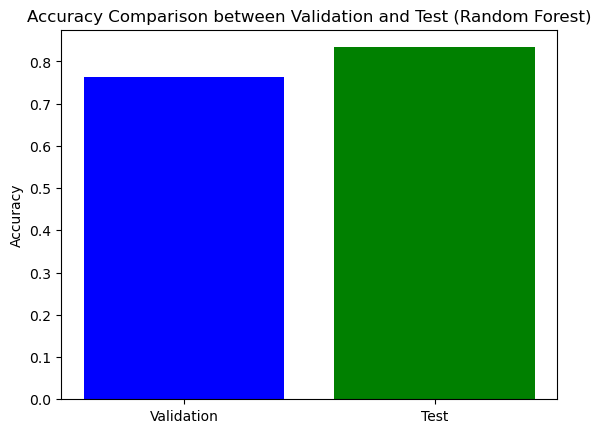

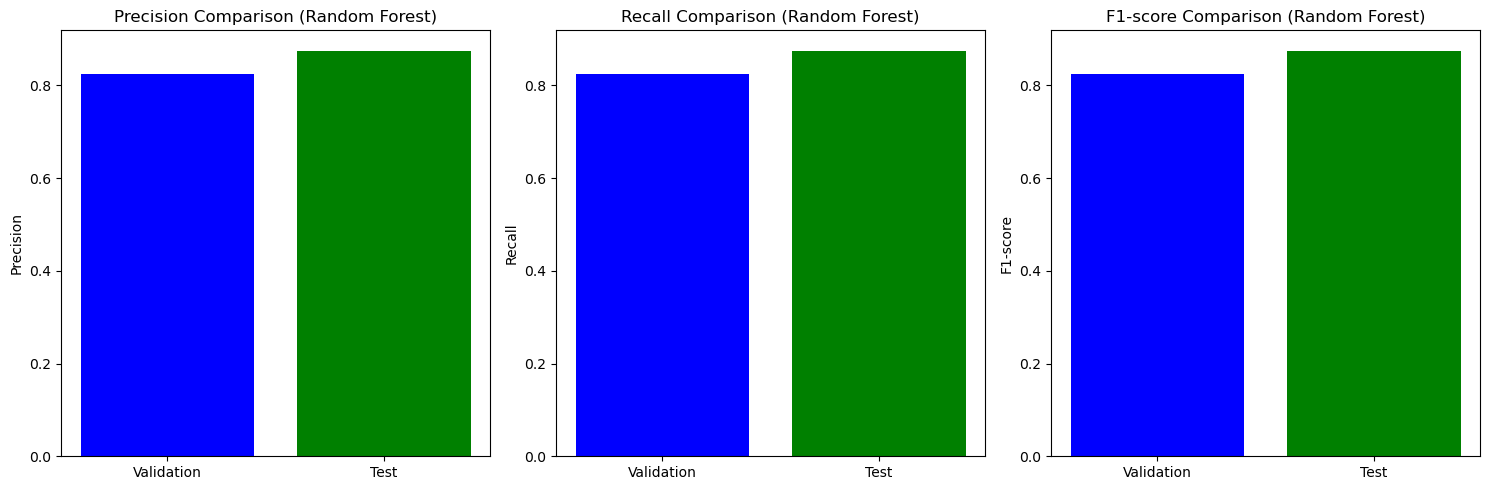

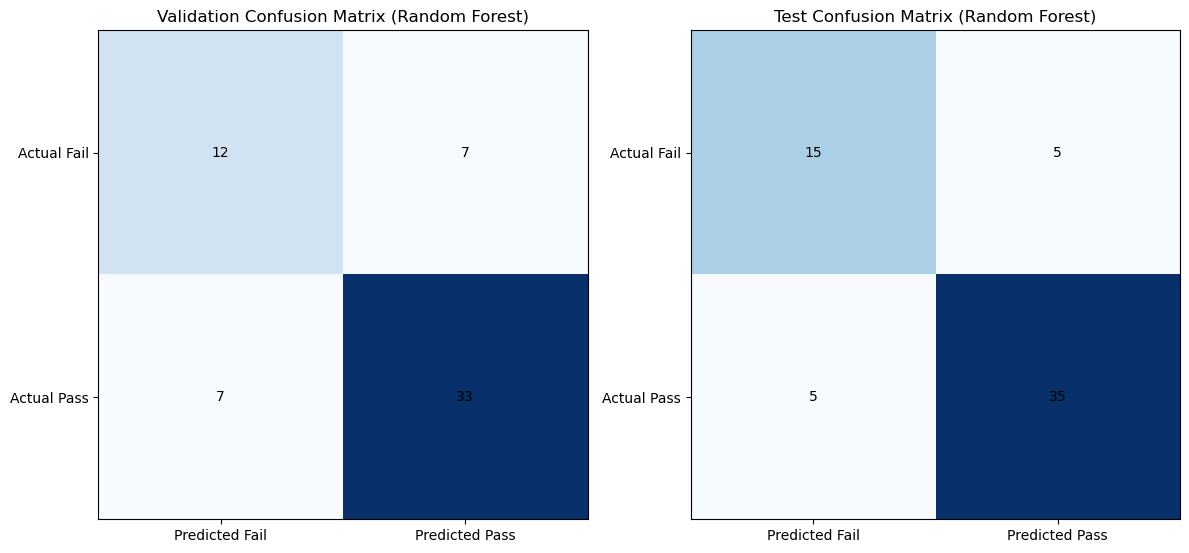

In [142]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Initialize Random Forest Classifier with default settings
rf_model = RandomForestClassifier(random_state=42)

# Train the model on the balanced, scaled training data
rf_model.fit(X_train_scaled, y_train_bal)

# Predictions on validation and test sets
y_val_pred_rf = rf_model.predict(X_val_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Calculate classification metrics
val_report_rf = classification_report(y_val, y_val_pred_rf, output_dict=True)
test_report_rf = classification_report(y_test, y_test_pred_rf, output_dict=True)

# Accuracy comparison
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

# Display classification report for validation set in the requested format
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_rf))

# Display classification report for test set in the requested format
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_rf))

# Display accuracy for validation and test sets
print("\nAccuracy Comparison:")
print(f"Validation Accuracy: {val_accuracy_rf:.4f}")
print(f"Test Accuracy: {test_accuracy_rf:.4f}")

# Plotting accuracy comparison between validation and test sets
fig, ax = plt.subplots()
ax.bar(['Validation', 'Test'], [val_accuracy_rf, test_accuracy_rf], color=['blue', 'green'])
ax.set_title('Accuracy Comparison between Validation and Test (Random Forest)')
ax.set_ylabel('Accuracy')
plt.show()

# Plotting other metrics comparison: precision, recall, and F1-score
metrics = ['precision', 'recall', 'f1-score']
metrics_values_rf = {metric: [val_report_rf['1'][metric], test_report_rf['1'][metric]] for metric in metrics}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(metrics):
    ax[i].bar(['Validation', 'Test'], metrics_values_rf[metric], color=['blue', 'green'])
    ax[i].set_title(f'{metric.capitalize()} Comparison (Random Forest)')
    ax[i].set_ylabel(metric.capitalize())
plt.tight_layout()
plt.show()

# Plotting confusion matrix for the Random Forest model with annotations
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# For Validation Confusion Matrix
val_conf_matrix_rf = confusion_matrix(y_val, y_val_pred_rf)
ax[0].imshow(val_conf_matrix_rf, cmap='Blues', interpolation='nearest')
ax[0].set_title('Validation Confusion Matrix (Random Forest)')
for i in range(val_conf_matrix_rf.shape[0]):
    for j in range(val_conf_matrix_rf.shape[1]):
        ax[0].text(j, i, str(val_conf_matrix_rf[i, j]), ha='center', va='center', color='black')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[0].set_yticklabels(['Actual Fail', 'Actual Pass'])

# For Test Confusion Matrix
test_conf_matrix_rf = confusion_matrix(y_test, y_test_pred_rf)
ax[1].imshow(test_conf_matrix_rf, cmap='Blues', interpolation='nearest')
ax[1].set_title('Test Confusion Matrix (Random Forest)')
for i in range(test_conf_matrix_rf.shape[0]):
    for j in range(test_conf_matrix_rf.shape[1]):
        ax[1].text(j, i, str(test_conf_matrix_rf[i, j]), ha='center', va='center', color='black')
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[1].set_yticklabels(['Actual Fail', 'Actual Pass'])

plt.tight_layout()
plt.show()


Best Parameters for Random Forest: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


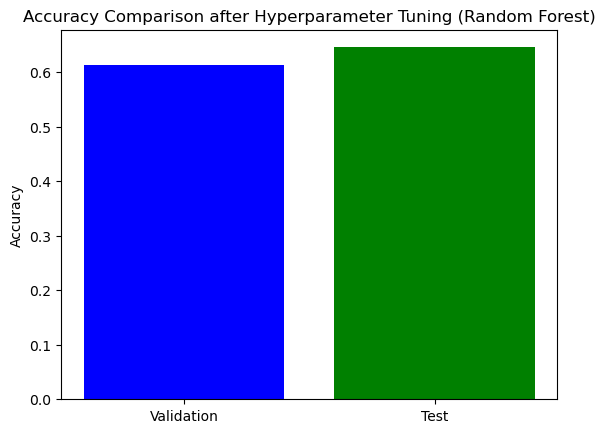

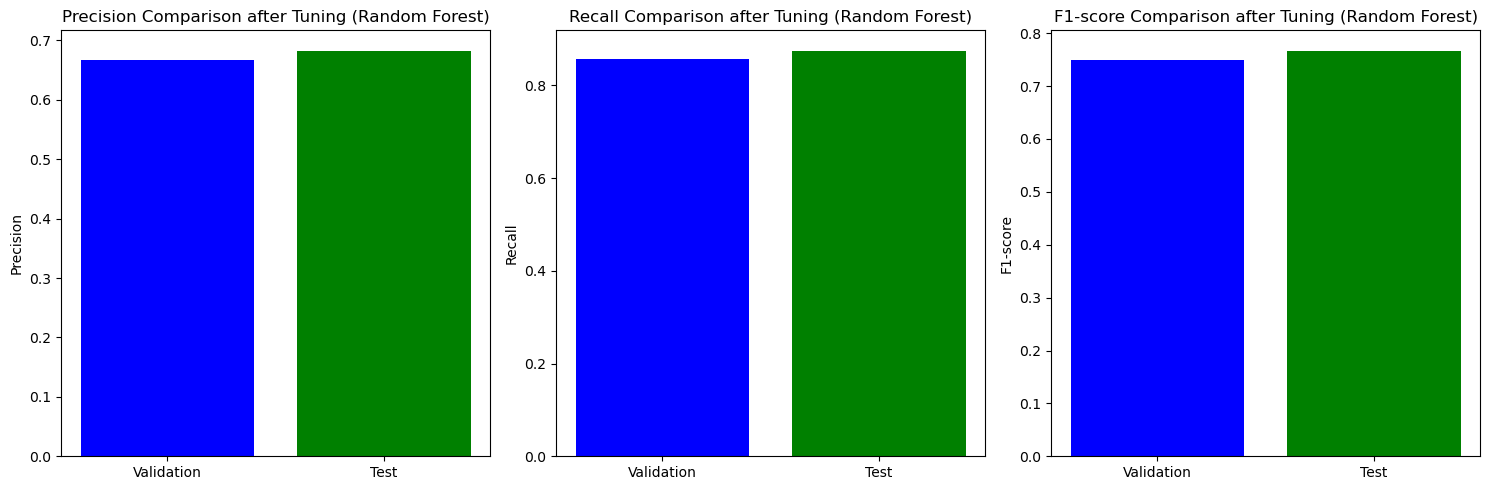

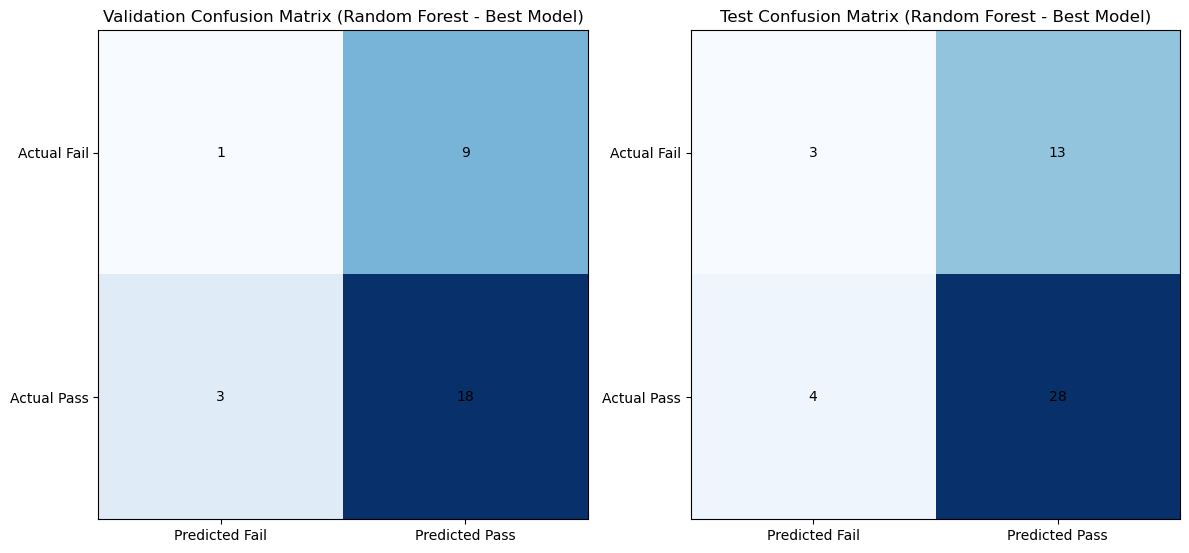

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

# Initialize Random Forest Classifier with class_weight='balanced' for class imbalance handling
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Updated parameter grid to align with previous suggestions
param_grid_rf = {
    "n_estimators": [50, 100, 200],             # Start with a reasonable range of estimators
    "max_depth": [3, 5, 10, 15, None],          # Restrict tree depth to prevent overfitting
    "min_samples_split": [2, 5, 10],             # Control the minimum samples required to split a node
    "min_samples_leaf": [1, 2, 4],               # Control the minimum samples required to be at a leaf node
    "max_features": ["sqrt", "log2", None],     # Limit the number of features to consider at each split
    "bootstrap": [True, False]                   # Bootstrap sampling; True is often better for Random Forest
}

# Initialize GridSearchCV with 5-fold cross-validation and recall as scoring metric
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, n_jobs=-1, scoring='recall')

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train_scaled, y_train_bal)

# Best parameters from grid search
best_params_rf = grid_search_rf.best_params_
print("Best Parameters for Random Forest:", best_params_rf)

# Best model from grid search
best_rf_model = grid_search_rf.best_estimator_

# Predictions on validation and test sets with the best model
y_val_pred_rf_best = best_rf_model.predict(X_val_scaled)
y_test_pred_rf_best = best_rf_model.predict(X_test_scaled)

# Classification metrics for the tuned model
val_report_rf_best = classification_report(y_val, y_val_pred_rf_best, output_dict=True)
test_report_rf_best = classification_report(y_test, y_test_pred_rf_best, output_dict=True)

# Accuracy comparison after hyperparameter tuning
val_accuracy_rf_best = accuracy_score(y_val, y_val_pred_rf_best)
test_accuracy_rf_best = accuracy_score(y_test, y_test_pred_rf_best)

# Plotting accuracy comparison after hyperparameter tuning
fig, ax = plt.subplots()
ax.bar(['Validation', 'Test'], [val_accuracy_rf_best, test_accuracy_rf_best], color=['blue', 'green'])
ax.set_title('Accuracy Comparison after Hyperparameter Tuning (Random Forest)')
ax.set_ylabel('Accuracy')
plt.show()

# Plotting other metrics comparison after tuning: precision, recall, and F1-score
metrics = ['precision', 'recall', 'f1-score']
metrics_values_rf_best = {metric: [val_report_rf_best['1'][metric], test_report_rf_best['1'][metric]] for metric in metrics}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(metrics):
    ax[i].bar(['Validation', 'Test'], metrics_values_rf_best[metric], color=['blue', 'green'])
    ax[i].set_title(f'{metric.capitalize()} Comparison after Tuning (Random Forest)')
    ax[i].set_ylabel(metric.capitalize())
plt.tight_layout()
plt.show()

# Plotting confusion matrix for the best model with annotations in black font
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# For Validation Confusion Matrix
val_conf_matrix_rf_best = confusion_matrix(y_val, y_val_pred_rf_best)
ax[0].imshow(val_conf_matrix_rf_best, cmap='Blues', interpolation='nearest')
ax[0].set_title('Validation Confusion Matrix (Random Forest - Best Model)')
for i in range(val_conf_matrix_rf_best.shape[0]):
    for j in range(val_conf_matrix_rf_best.shape[1]):
        ax[0].text(j, i, str(val_conf_matrix_rf_best[i, j]), ha='center', va='center', color='black')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[0].set_yticklabels(['Actual Fail', 'Actual Pass'])

# For Test Confusion Matrix
test_conf_matrix_rf_best = confusion_matrix(y_test, y_test_pred_rf_best)
ax[1].imshow(test_conf_matrix_rf_best, cmap='Blues', interpolation='nearest')
ax[1].set_title('Test Confusion Matrix (Random Forest - Best Model)')
for i in range(test_conf_matrix_rf_best.shape[0]):
    for j in range(test_conf_matrix_rf_best.shape[1]):
        ax[1].text(j, i, str(test_conf_matrix_rf_best[i, j]), ha='center', va='center', color='black')
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[1].set_yticklabels(['Actual Fail', 'Actual Pass'])

plt.tight_layout()
plt.show()


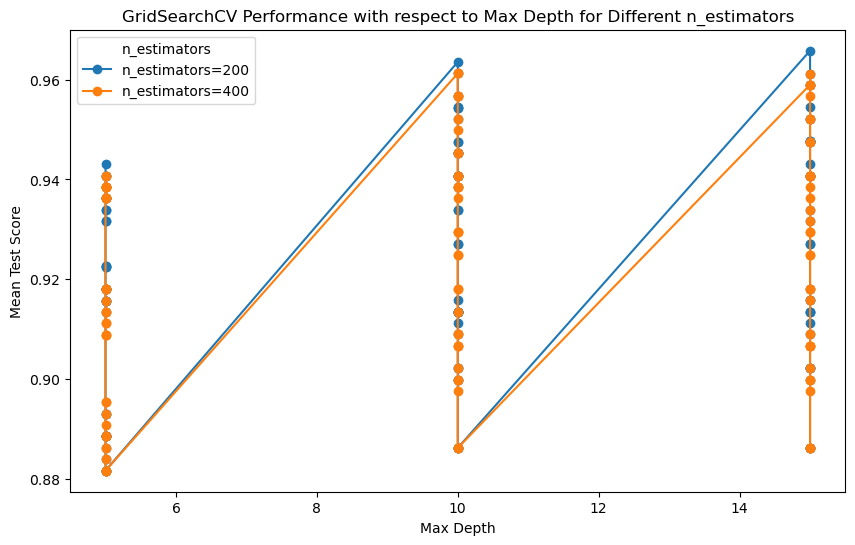

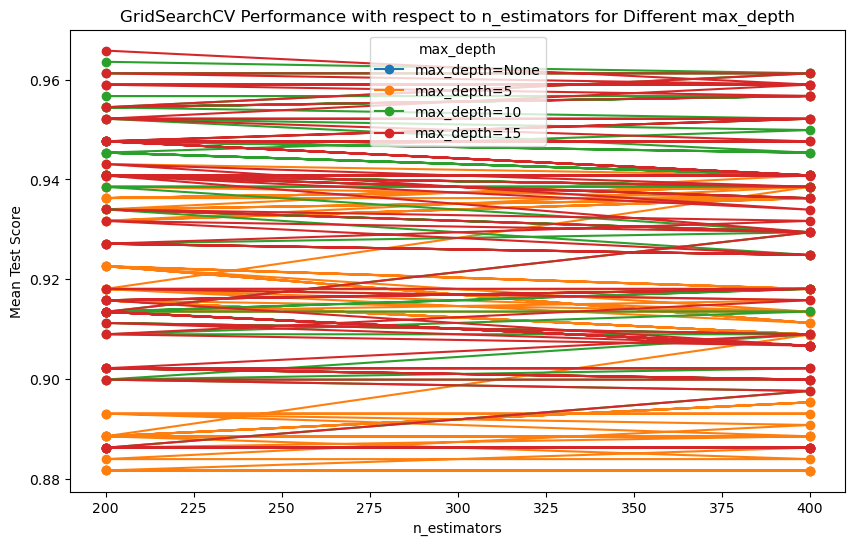

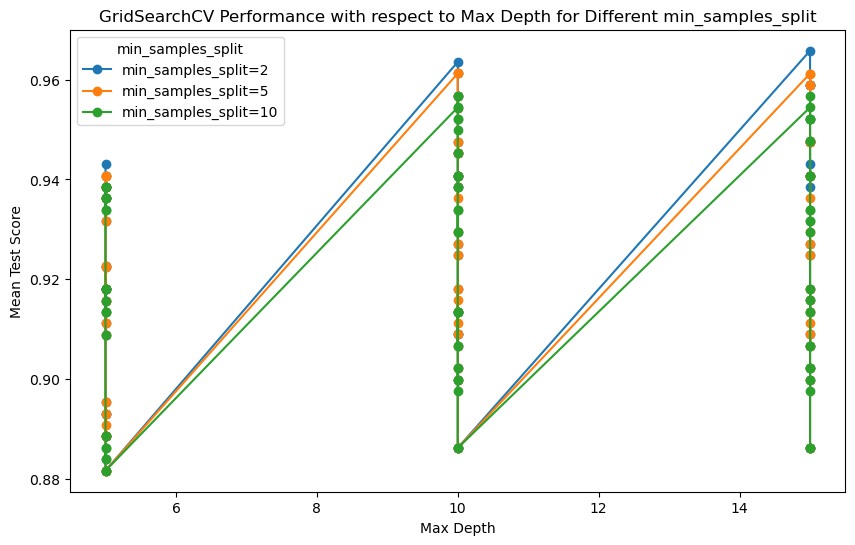

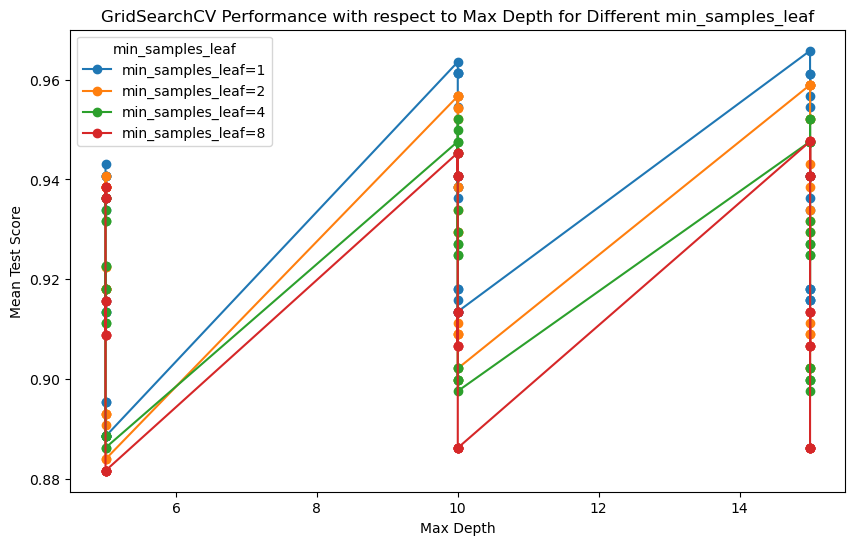

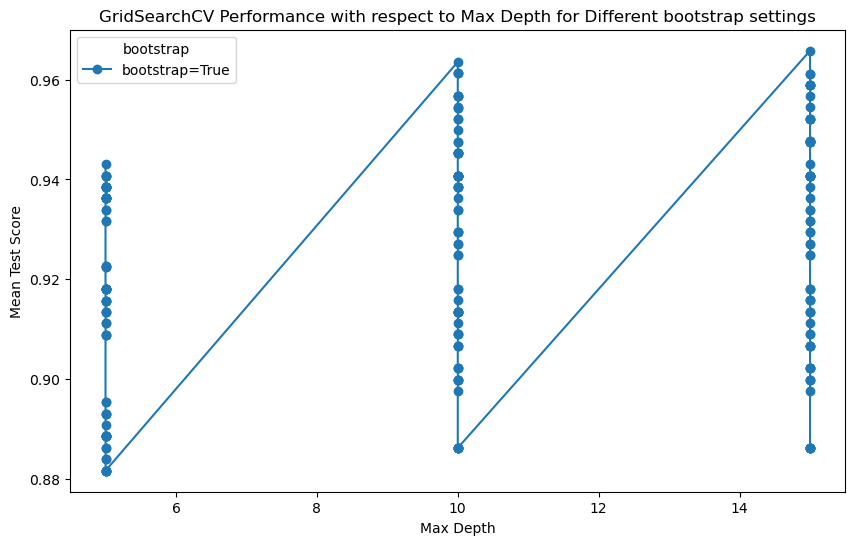

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the grid search results as a DataFrame
results_rf = pd.DataFrame(grid_search_rf.cv_results_)

# Plot for n_estimators vs mean_test_score
plt.figure(figsize=(10, 6))
for n_estimators in results_rf['param_n_estimators'].unique():
    subset = results_rf[results_rf['param_n_estimators'] == n_estimators]
    plt.plot(subset['param_max_depth'], subset['mean_test_score'], label=f'n_estimators={n_estimators}', marker='o')
plt.title('GridSearchCV Performance with respect to Max Depth for Different n_estimators')
plt.xlabel('Max Depth')
plt.ylabel('Mean Test Score')
plt.legend(title='n_estimators')
plt.show()

# Plot for max_depth vs mean_test_score
plt.figure(figsize=(10, 6))
for max_depth in results_rf['param_max_depth'].unique():
    subset = results_rf[results_rf['param_max_depth'] == max_depth]
    plt.plot(subset['param_n_estimators'], subset['mean_test_score'], label=f'max_depth={max_depth}', marker='o')
plt.title('GridSearchCV Performance with respect to n_estimators for Different max_depth')
plt.xlabel('n_estimators')
plt.ylabel('Mean Test Score')
plt.legend(title='max_depth')
plt.show()

# Plot for min_samples_split vs mean_test_score
plt.figure(figsize=(10, 6))
for min_samples_split in results_rf['param_min_samples_split'].unique():
    subset = results_rf[results_rf['param_min_samples_split'] == min_samples_split]
    plt.plot(subset['param_max_depth'], subset['mean_test_score'], label=f'min_samples_split={min_samples_split}', marker='o')
plt.title('GridSearchCV Performance with respect to Max Depth for Different min_samples_split')
plt.xlabel('Max Depth')
plt.ylabel('Mean Test Score')
plt.legend(title='min_samples_split')
plt.show()

# Plot for min_samples_leaf vs mean_test_score
plt.figure(figsize=(10, 6))
for min_samples_leaf in results_rf['param_min_samples_leaf'].unique():
    subset = results_rf[results_rf['param_min_samples_leaf'] == min_samples_leaf]
    plt.plot(subset['param_max_depth'], subset['mean_test_score'], label=f'min_samples_leaf={min_samples_leaf}', marker='o')
plt.title('GridSearchCV Performance with respect to Max Depth for Different min_samples_leaf')
plt.xlabel('Max Depth')
plt.ylabel('Mean Test Score')
plt.legend(title='min_samples_leaf')
plt.show()

# Plot for bootstrap vs mean_test_score
plt.figure(figsize=(10, 6))
for bootstrap in results_rf['param_bootstrap'].unique():
    subset = results_rf[results_rf['param_bootstrap'] == bootstrap]
    plt.plot(subset['param_max_depth'], subset['mean_test_score'], label=f'bootstrap={bootstrap}', marker='o')
plt.title('GridSearchCV Performance with respect to Max Depth for Different bootstrap settings')
plt.xlabel('Max Depth')
plt.ylabel('Mean Test Score')
plt.legend(title='bootstrap')
plt.show()


Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.50      0.26      0.34        19
           1       0.71      0.88      0.79        40

    accuracy                           0.68        59
   macro avg       0.61      0.57      0.57        59
weighted avg       0.65      0.68      0.64        59


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.67      0.30      0.41        20
           1       0.73      0.93      0.81        40

    accuracy                           0.72        60
   macro avg       0.70      0.61      0.61        60
weighted avg       0.71      0.72      0.68        60


Accuracy Comparison:
Validation Accuracy: 0.6780
Test Accuracy: 0.7167


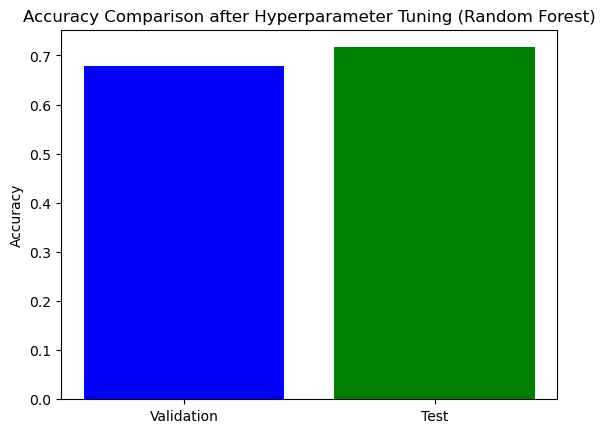

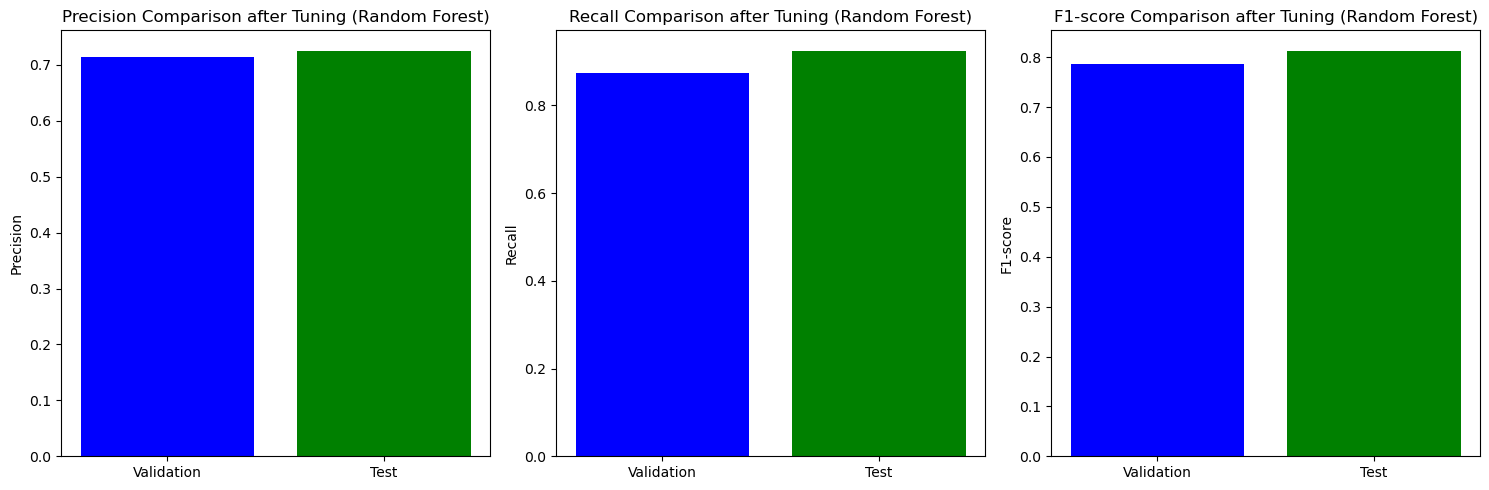

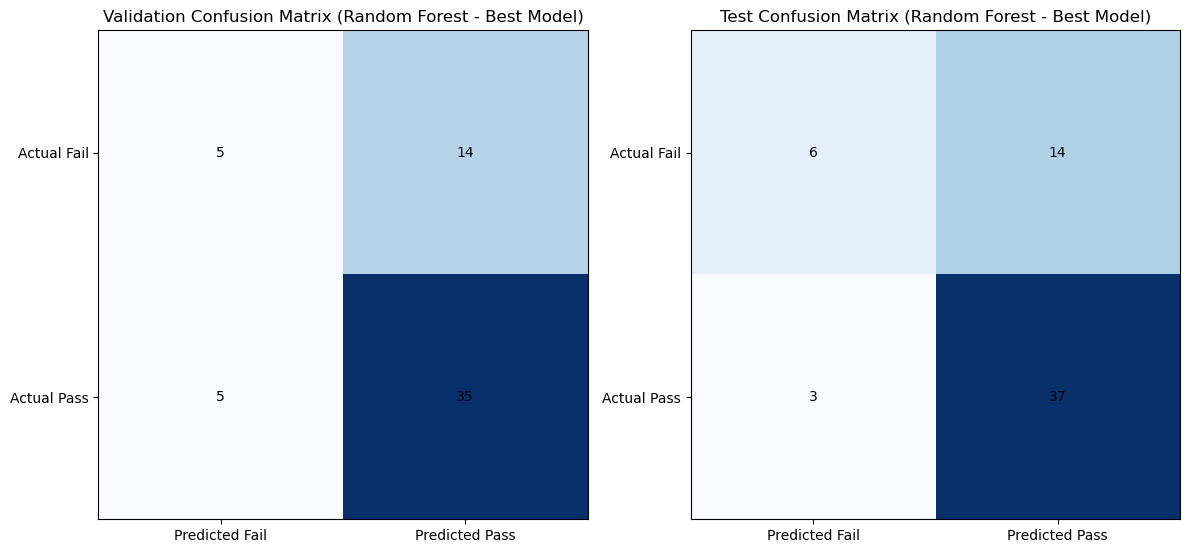

In [181]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

# Best Parameters for Random Forest
best_rf_params = {
    'bootstrap': True,
    'max_depth': 10,
    'max_features': 'sqrt',
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 50
}

# Initialize Random Forest Classifier with the best hyperparameters
best_rf_model = RandomForestClassifier(**best_rf_params, random_state=42)

# Train the model on the balanced, scaled training data
best_rf_model.fit(X_train_scaled, y_train_bal)

# Predictions on validation and test sets with the best model
y_val_pred_rf_best = best_rf_model.predict(X_val_scaled)
y_test_pred_rf_best = best_rf_model.predict(X_test_scaled)

# Classification metrics for the tuned model
val_report_rf_best = classification_report(y_val, y_val_pred_rf_best, output_dict=True)
test_report_rf_best = classification_report(y_test, y_test_pred_rf_best, output_dict=True)

# Accuracy comparison after hyperparameter tuning
val_accuracy_rf_best = accuracy_score(y_val, y_val_pred_rf_best)
test_accuracy_rf_best = accuracy_score(y_test, y_test_pred_rf_best)

# Print Classification Report for Validation Set
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_rf_best))

# Print Classification Report for Test Set
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_rf_best))

# Print Accuracy Comparison
print("\nAccuracy Comparison:")
print(f"Validation Accuracy: {val_accuracy_rf_best:.4f}")
print(f"Test Accuracy: {test_accuracy_rf_best:.4f}")

# Plotting accuracy comparison after hyperparameter tuning
fig, ax = plt.subplots()
ax.bar(['Validation', 'Test'], [val_accuracy_rf_best, test_accuracy_rf_best], color=['blue', 'green'])
ax.set_title('Accuracy Comparison after Hyperparameter Tuning (Random Forest)')
ax.set_ylabel('Accuracy')
plt.show()

# Plotting other metrics comparison after tuning: precision, recall, and F1-score
metrics_values_rf_best = {metric: [val_report_rf_best['1'][metric], test_report_rf_best['1'][metric]] for metric in ['precision', 'recall', 'f1-score']}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(['precision', 'recall', 'f1-score']):
    ax[i].bar(['Validation', 'Test'], metrics_values_rf_best[metric], color=['blue', 'green'])
    ax[i].set_title(f'{metric.capitalize()} Comparison after Tuning (Random Forest)')
    ax[i].set_ylabel(metric.capitalize())
plt.tight_layout()
plt.show()

# Plotting confusion matrix for the Random Forest model with annotations
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# For Validation Confusion Matrix
val_conf_matrix_rf_best = confusion_matrix(y_val, y_val_pred_rf_best)
ax[0].imshow(val_conf_matrix_rf_best, cmap='Blues', interpolation='nearest')
ax[0].set_title('Validation Confusion Matrix (Random Forest - Best Model)')
for i in range(val_conf_matrix_rf_best.shape[0]):
    for j in range(val_conf_matrix_rf_best.shape[1]):
        ax[0].text(j, i, str(val_conf_matrix_rf_best[i, j]), ha='center', va='center', color='black')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[0].set_yticklabels(['Actual Fail', 'Actual Pass'])

# For Test Confusion Matrix
test_conf_matrix_rf_best = confusion_matrix(y_test, y_test_pred_rf_best)
ax[1].imshow(test_conf_matrix_rf_best, cmap='Blues', interpolation='nearest')
ax[1].set_title('Test Confusion Matrix (Random Forest - Best Model)')
for i in range(test_conf_matrix_rf_best.shape[0]):
    for j in range(test_conf_matrix_rf_best.shape[1]):
        ax[1].text(j, i, str(test_conf_matrix_rf_best[i, j]), ha='center', va='center', color='black')
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[1].set_yticklabels(['Actual Fail', 'Actual Pass'])

plt.tight_layout()
plt.show()


In [52]:
# Prepare a table of performance metrics
metrics_table_rf = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Validation': [
        val_accuracy_rf_best,
        val_report_rf_best['1']['precision'],
        val_report_rf_best['1']['recall'],
        val_report_rf_best['1']['f1-score']
    ],
    'Test': [
        test_accuracy_rf_best,
        test_report_rf_best['1']['precision'],
        test_report_rf_best['1']['recall'],
        test_report_rf_best['1']['f1-score']
    ]
}

# Convert the dictionary into a DataFrame for better readability
metrics_df_rf = pd.DataFrame(metrics_table_rf)

# Display the table
print(metrics_df_rf)


      Metric  Validation      Test
0   Accuracy    0.612903  0.666667
1  Precision    0.695652  0.690476
2     Recall    0.761905  0.906250
3   F1-Score    0.727273  0.783784


In [ ]:
#GRADIENT BOOST

Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.63      0.71      0.67        17
           1       0.85      0.81      0.83        36

    accuracy                           0.77        53
   macro avg       0.74      0.76      0.75        53
weighted avg       0.78      0.77      0.78        53


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.67      0.73      0.70        22
           1       0.86      0.82      0.84        44

    accuracy                           0.79        66
   macro avg       0.76      0.77      0.77        66
weighted avg       0.79      0.79      0.79        66


Accuracy Comparison:
Validation Accuracy: 0.7736
Test Accuracy: 0.7879


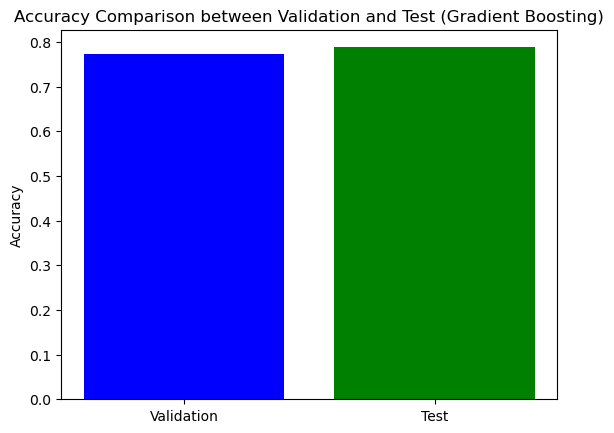

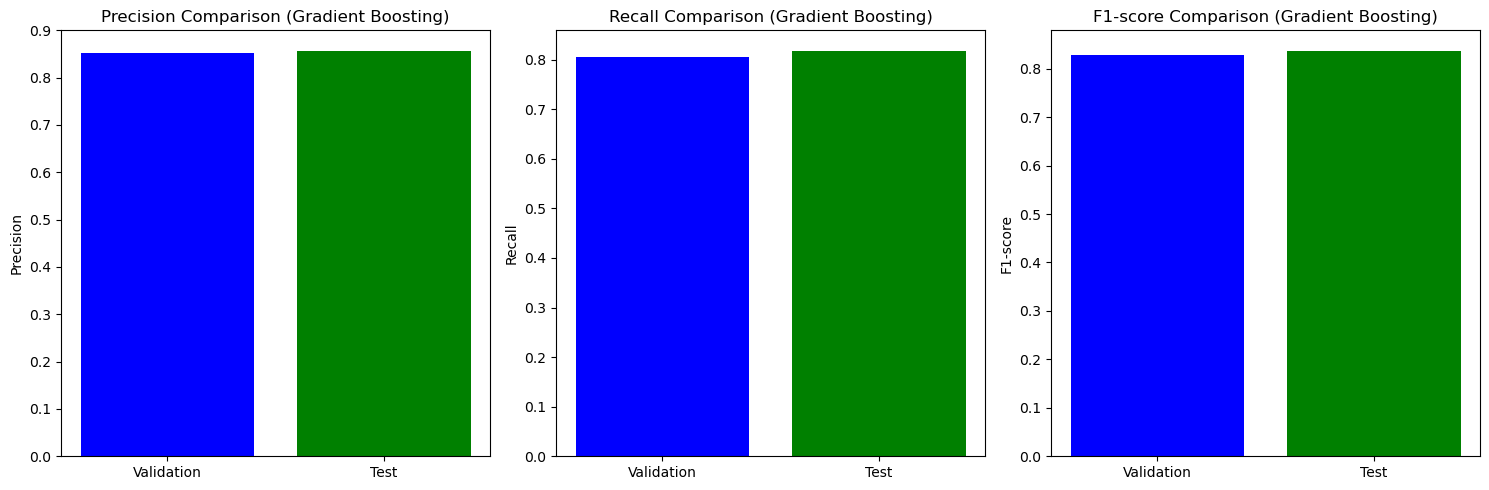

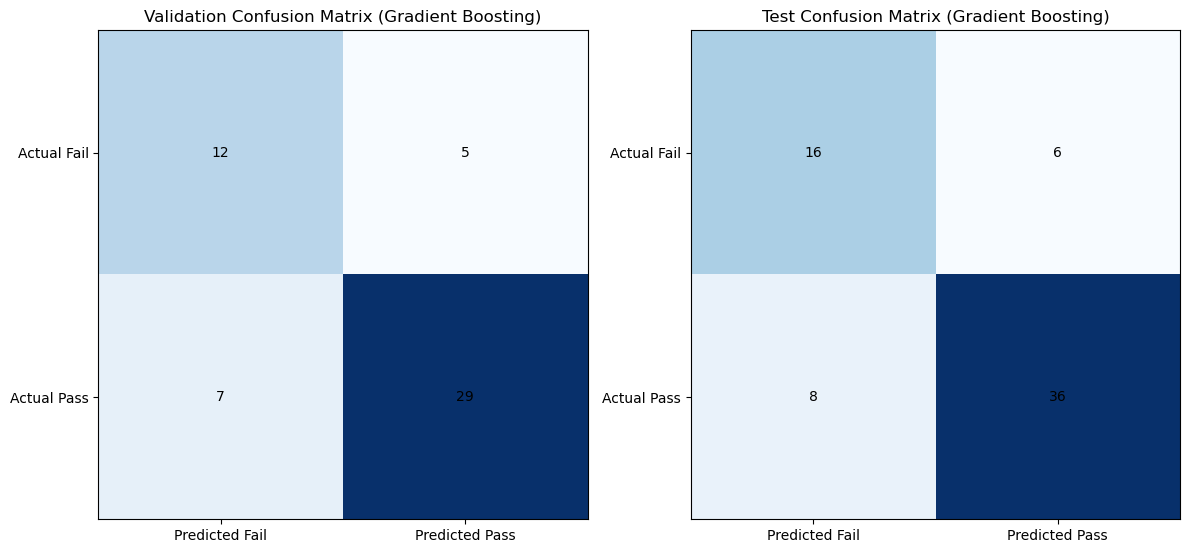

In [209]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Initialize Gradient Boosting Classifier with default settings
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model on the balanced, scaled training data
gb_model.fit(X_train_scaled, y_train_bal)

# Predictions on validation and test sets
y_val_pred_gb = gb_model.predict(X_val_scaled)
y_test_pred_gb = gb_model.predict(X_test_scaled)

# Classification metrics for the tuned model
val_report_gb = classification_report(y_val, y_val_pred_gb, output_dict=True)
test_report_gb = classification_report(y_test, y_test_pred_gb, output_dict=True)

# Accuracy comparison
val_accuracy_gb = accuracy_score(y_val, y_val_pred_gb)
test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)

# Print Classification Report for Validation Set
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_gb))

# Print Classification Report for Test Set
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_gb))

# Print Accuracy Comparison
print("\nAccuracy Comparison:")
print(f"Validation Accuracy: {val_accuracy_gb:.4f}")
print(f"Test Accuracy: {test_accuracy_gb:.4f}")

# Plotting accuracy comparison between validation and test sets
fig, ax = plt.subplots()
ax.bar(['Validation', 'Test'], [val_accuracy_gb, test_accuracy_gb], color=['blue', 'green'])
ax.set_title('Accuracy Comparison between Validation and Test (Gradient Boosting)')
ax.set_ylabel('Accuracy')
plt.show()

# Plotting other metrics comparison after tuning: precision, recall, and F1-score
metrics_values_gb = {metric: [val_report_gb['1'][metric], test_report_gb['1'][metric]] for metric in ['precision', 'recall', 'f1-score']}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(['precision', 'recall', 'f1-score']):
    ax[i].bar(['Validation', 'Test'], metrics_values_gb[metric], color=['blue', 'green'])
    ax[i].set_title(f'{metric.capitalize()} Comparison (Gradient Boosting)')
    ax[i].set_ylabel(metric.capitalize())
plt.tight_layout()
plt.show()

# Plotting confusion matrix for the Gradient Boosting model with annotations
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# For Validation Confusion Matrix
val_conf_matrix_gb = confusion_matrix(y_val, y_val_pred_gb)
ax[0].imshow(val_conf_matrix_gb, cmap='Blues', interpolation='nearest')
ax[0].set_title('Validation Confusion Matrix (Gradient Boosting)')
for i in range(val_conf_matrix_gb.shape[0]):
    for j in range(val_conf_matrix_gb.shape[1]):
        ax[0].text(j, i, str(val_conf_matrix_gb[i, j]), ha='center', va='center', color='black')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[0].set_yticklabels(['Actual Fail', 'Actual Pass'])

# For Test Confusion Matrix
test_conf_matrix_gb = confusion_matrix(y_test, y_test_pred_gb)
ax[1].imshow(test_conf_matrix_gb, cmap='Blues', interpolation='nearest')
ax[1].set_title('Test Confusion Matrix (Gradient Boosting)')
for i in range(test_conf_matrix_gb.shape[0]):
    for j in range(test_conf_matrix_gb.shape[1]):
        ax[1].text(j, i, str(test_conf_matrix_gb[i, j]), ha='center', va='center', color='black')
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[1].set_yticklabels(['Actual Fail', 'Actual Pass'])

plt.tight_layout()
plt.show()


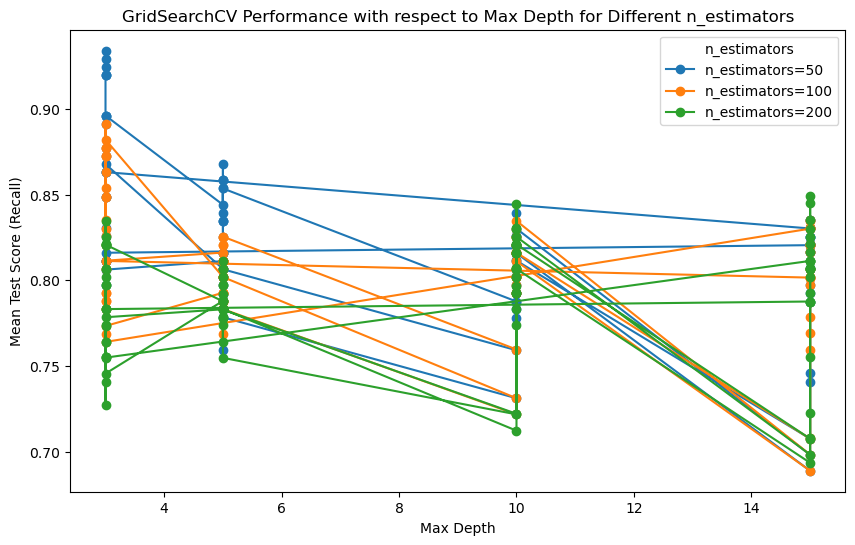

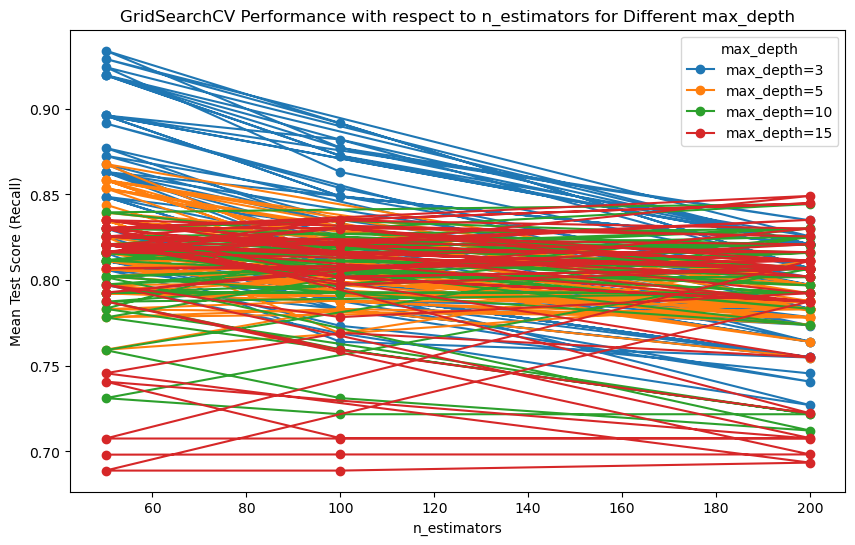

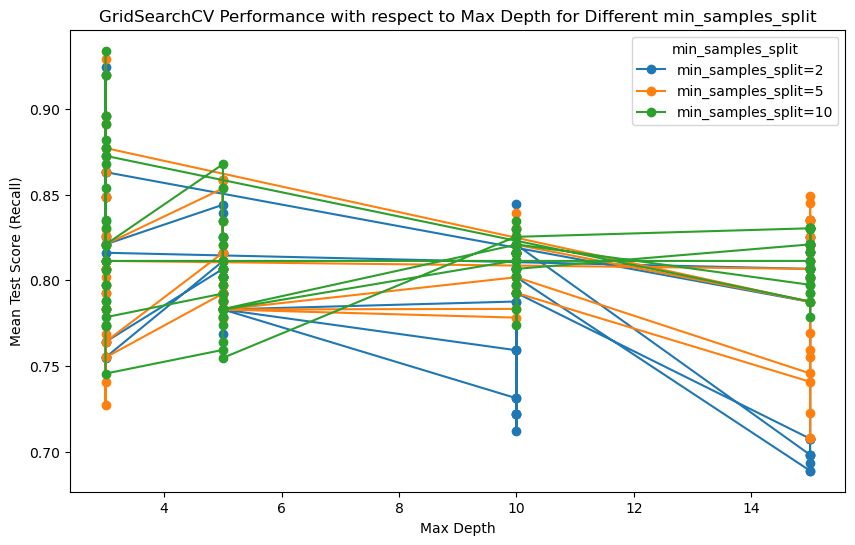

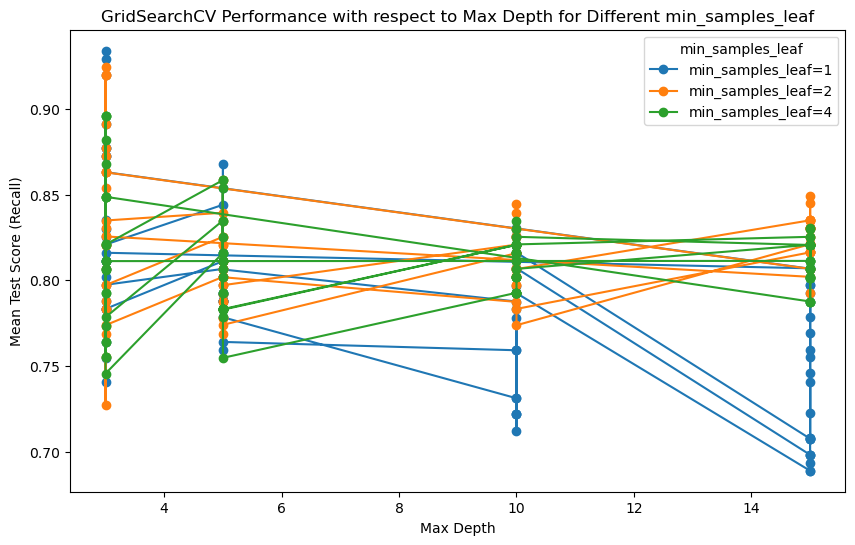

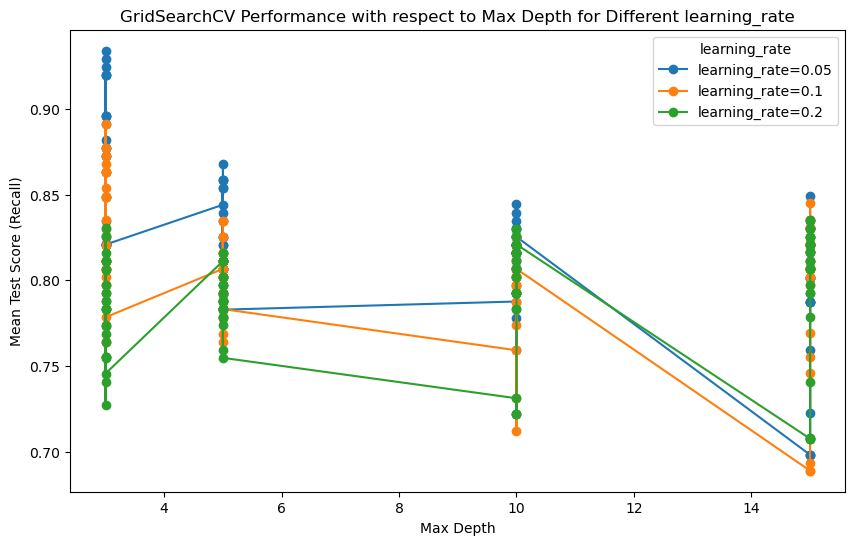

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Initialize Gradient Boosting Classifier with default settings
gb_model = GradientBoostingClassifier(random_state=42)

# Define parameter grid for hyperparameter tuning
param_grid_gb = {
    'n_estimators': [50, 100, 200],                # Number of boosting stages
    'learning_rate': [0.05, 0.1, 0.2],             # Step size at each iteration
    'max_depth': [3, 5, 10, 15],                    # Limit tree depth to avoid overfitting
    'min_samples_split': [2, 5, 10],                 # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],                   # Minimum samples required at a leaf node
}

# Initialize GridSearchCV with 5-fold cross-validation and recall as scoring metric
grid_search_gb = GridSearchCV(estimator=gb_model, param_grid=param_grid_gb, cv=5, n_jobs=-1, scoring='recall')

# Fit GridSearchCV to the training data
grid_search_gb.fit(X_train_scaled, y_train_bal)

# Get the grid search results as a DataFrame
results_gb = pd.DataFrame(grid_search_gb.cv_results_)

# Plot for n_estimators vs mean_test_score
plt.figure(figsize=(10, 6))
for n_estimators in results_gb['param_n_estimators'].unique():
    subset = results_gb[results_gb['param_n_estimators'] == n_estimators]
    plt.plot(subset['param_max_depth'], subset['mean_test_score'], label=f'n_estimators={n_estimators}', marker='o')
plt.title('GridSearchCV Performance with respect to Max Depth for Different n_estimators')
plt.xlabel('Max Depth')
plt.ylabel('Mean Test Score (Recall)')
plt.legend(title='n_estimators')
plt.show()

# Plot for max_depth vs mean_test_score
plt.figure(figsize=(10, 6))
for max_depth in results_gb['param_max_depth'].unique():
    subset = results_gb[results_gb['param_max_depth'] == max_depth]
    plt.plot(subset['param_n_estimators'], subset['mean_test_score'], label=f'max_depth={max_depth}', marker='o')
plt.title('GridSearchCV Performance with respect to n_estimators for Different max_depth')
plt.xlabel('n_estimators')
plt.ylabel('Mean Test Score (Recall)')
plt.legend(title='max_depth')
plt.show()

# Plot for min_samples_split vs mean_test_score
plt.figure(figsize=(10, 6))
for min_samples_split in results_gb['param_min_samples_split'].unique():
    subset = results_gb[results_gb['param_min_samples_split'] == min_samples_split]
    plt.plot(subset['param_max_depth'], subset['mean_test_score'], label=f'min_samples_split={min_samples_split}', marker='o')
plt.title('GridSearchCV Performance with respect to Max Depth for Different min_samples_split')
plt.xlabel('Max Depth')
plt.ylabel('Mean Test Score (Recall)')
plt.legend(title='min_samples_split')
plt.show()

# Plot for min_samples_leaf vs mean_test_score
plt.figure(figsize=(10, 6))
for min_samples_leaf in results_gb['param_min_samples_leaf'].unique():
    subset = results_gb[results_gb['param_min_samples_leaf'] == min_samples_leaf]
    plt.plot(subset['param_max_depth'], subset['mean_test_score'], label=f'min_samples_leaf={min_samples_leaf}', marker='o')
plt.title('GridSearchCV Performance with respect to Max Depth for Different min_samples_leaf')
plt.xlabel('Max Depth')
plt.ylabel('Mean Test Score (Recall)')
plt.legend(title='min_samples_leaf')
plt.show()

# Plot for learning_rate vs mean_test_score
plt.figure(figsize=(10, 6))
for learning_rate in results_gb['param_learning_rate'].unique():
    subset = results_gb[results_gb['param_learning_rate'] == learning_rate]
    plt.plot(subset['param_max_depth'], subset['mean_test_score'], label=f'learning_rate={learning_rate}', marker='o')
plt.title('GridSearchCV Performance with respect to Max Depth for Different learning_rate')
plt.xlabel('Max Depth')
plt.ylabel('Mean Test Score (Recall)')
plt.legend(title='learning_rate')
plt.show()


In [54]:
# After fitting the grid search, you can access the best parameters like this:
print("Best Parameters for Gradient Boosting:")
print(grid_search_gb.best_params_)

# You can also print the best model if needed
best_gb_model = grid_search_gb.best_estimator_
print("Best Gradient Boosting Model:", best_gb_model)


Best Parameters for Gradient Boosting:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Best Gradient Boosting Model: GradientBoostingClassifier(learning_rate=0.05, min_samples_split=10,
                           n_estimators=50, random_state=42)


Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.67      0.82      0.74        17
           1       0.91      0.81      0.85        36

    accuracy                           0.81        53
   macro avg       0.79      0.81      0.79        53
weighted avg       0.83      0.81      0.82        53


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.68      0.86      0.76        22
           1       0.92      0.80      0.85        44

    accuracy                           0.82        66
   macro avg       0.80      0.83      0.81        66
weighted avg       0.84      0.82      0.82        66


Accuracy Comparison:
Validation Accuracy: 0.8113
Test Accuracy: 0.8182


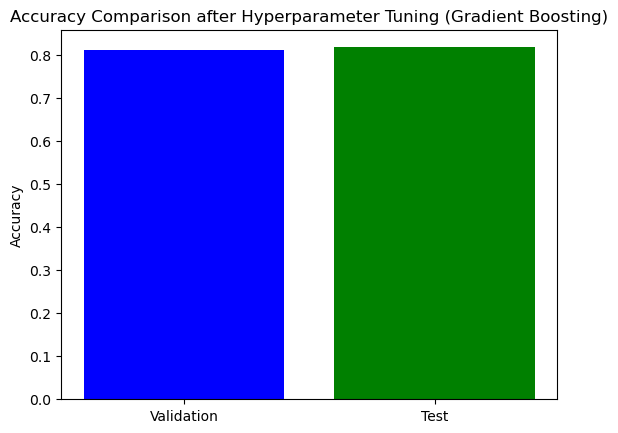

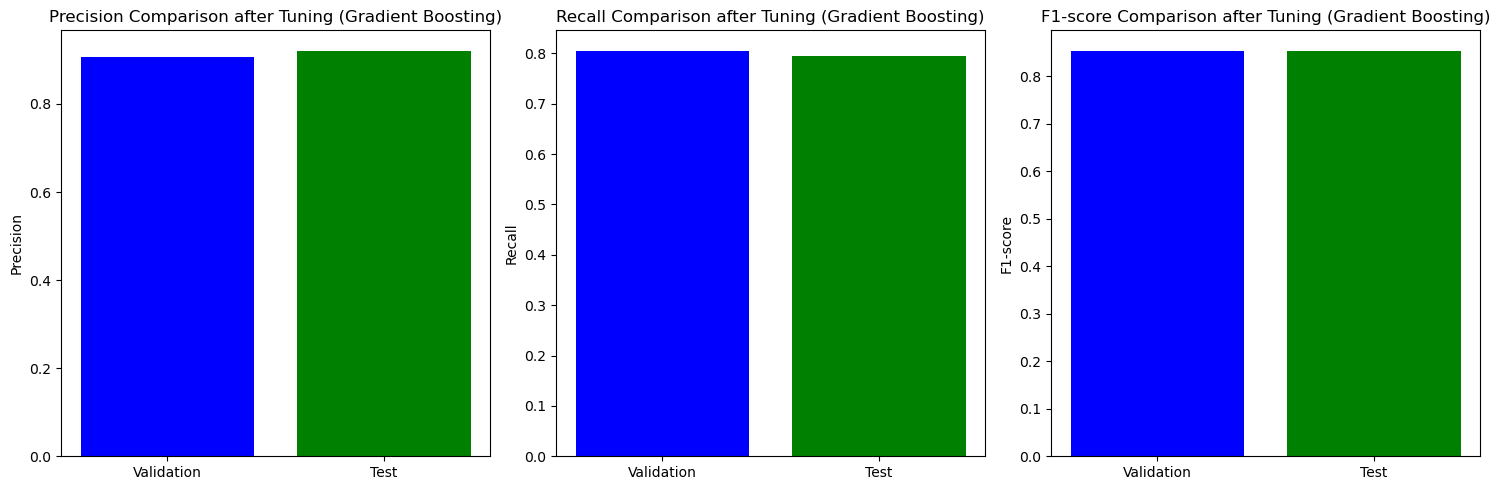

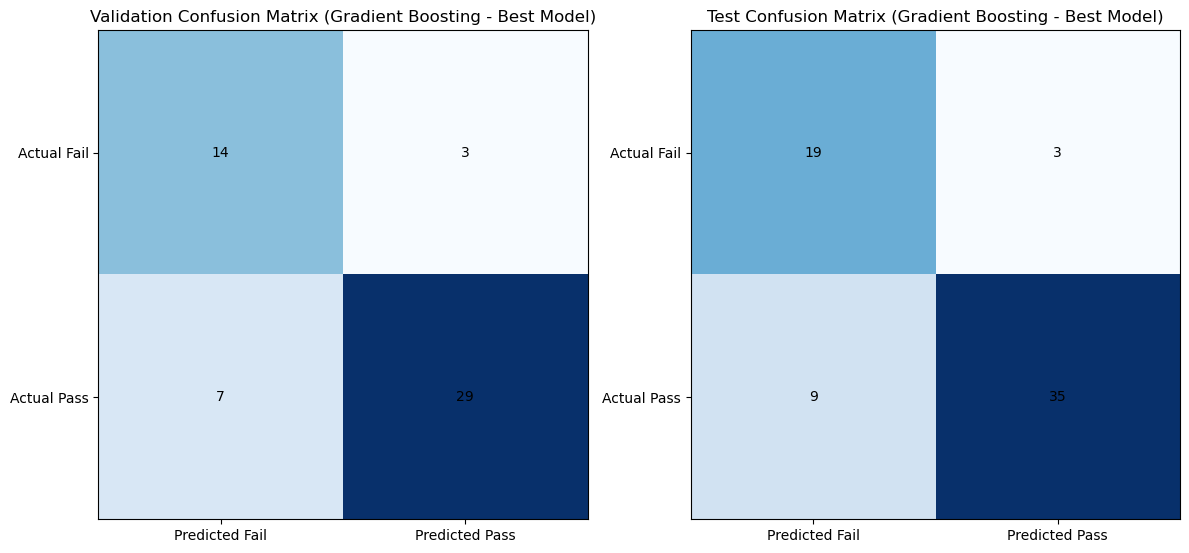

In [208]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

# Best Parameters for Gradient Boosting
best_gb_params = {
    'learning_rate': 0.05,
    'max_depth': 5,
    'min_samples_leaf': 1,
    'min_samples_split': 3,
    'n_estimators': 50,
    'random_state': 42
}

# Initialize Gradient Boosting Classifier with the best hyperparameters
best_gb_model = GradientBoostingClassifier(**best_gb_params)

# Train the model on the balanced, scaled training data
best_gb_model.fit(X_train_scaled, y_train_bal)

# Predictions on validation and test sets with the best model
y_val_pred_gb_best = best_gb_model.predict(X_val_scaled)
y_test_pred_gb_best = best_gb_model.predict(X_test_scaled)

# Classification metrics for the tuned model
val_report_gb_best = classification_report(y_val, y_val_pred_gb_best, output_dict=True)
test_report_gb_best = classification_report(y_test, y_test_pred_gb_best, output_dict=True)

# Accuracy comparison after hyperparameter tuning
val_accuracy_gb_best = accuracy_score(y_val, y_val_pred_gb_best)
test_accuracy_gb_best = accuracy_score(y_test, y_test_pred_gb_best)

# Print Classification Report for Validation Set
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_gb_best))

# Print Classification Report for Test Set
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_gb_best))

# Print Accuracy Comparison
print("\nAccuracy Comparison:")
print(f"Validation Accuracy: {val_accuracy_gb_best:.4f}")
print(f"Test Accuracy: {test_accuracy_gb_best:.4f}")

# Plotting accuracy comparison after hyperparameter tuning
fig, ax = plt.subplots()
ax.bar(['Validation', 'Test'], [val_accuracy_gb_best, test_accuracy_gb_best], color=['blue', 'green'])
ax.set_title('Accuracy Comparison after Hyperparameter Tuning (Gradient Boosting)')
ax.set_ylabel('Accuracy')
plt.show()

# Plotting other metrics comparison after tuning: precision, recall, and F1-score
metrics_values_gb_best = {metric: [val_report_gb_best['1'][metric], test_report_gb_best['1'][metric]] for metric in ['precision', 'recall', 'f1-score']}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(['precision', 'recall', 'f1-score']):
    ax[i].bar(['Validation', 'Test'], metrics_values_gb_best[metric], color=['blue', 'green'])
    ax[i].set_title(f'{metric.capitalize()} Comparison after Tuning (Gradient Boosting)')
    ax[i].set_ylabel(metric.capitalize())
plt.tight_layout()
plt.show()

# Plotting confusion matrix for the Gradient Boosting model with annotations
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# For Validation Confusion Matrix
val_conf_matrix_gb_best = confusion_matrix(y_val, y_val_pred_gb_best)
ax[0].imshow(val_conf_matrix_gb_best, cmap='Blues', interpolation='nearest')
ax[0].set_title('Validation Confusion Matrix (Gradient Boosting - Best Model)')
for i in range(val_conf_matrix_gb_best.shape[0]):
    for j in range(val_conf_matrix_gb_best.shape[1]):
        ax[0].text(j, i, str(val_conf_matrix_gb_best[i, j]), ha='center', va='center', color='black')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[0].set_yticklabels(['Actual Fail', 'Actual Pass'])

# For Test Confusion Matrix
test_conf_matrix_gb_best = confusion_matrix(y_test, y_test_pred_gb_best)
ax[1].imshow(test_conf_matrix_gb_best, cmap='Blues', interpolation='nearest')
ax[1].set_title('Test Confusion Matrix (Gradient Boosting - Best Model)')
for i in range(test_conf_matrix_gb_best.shape[0]):
    for j in range(test_conf_matrix_gb_best.shape[1]):
        ax[1].text(j, i, str(test_conf_matrix_gb_best[i, j]), ha='center', va='center', color='black')
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[1].set_yticklabels(['Actual Fail', 'Actual Pass'])

plt.tight_layout()
plt.show()


In [ ]:
#ADABOOST

c:\Users\Rifat\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.59      0.68      0.63        19
           1       0.84      0.78      0.81        40

    accuracy                           0.75        59
   macro avg       0.71      0.73      0.72        59
weighted avg       0.76      0.75      0.75        59


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.68      0.65      0.67        20
           1       0.83      0.85      0.84        40

    accuracy                           0.78        60
   macro avg       0.76      0.75      0.75        60
weighted avg       0.78      0.78      0.78        60


Accuracy Comparison:
Validation Accuracy: 0.7458
Test Accuracy: 0.7833


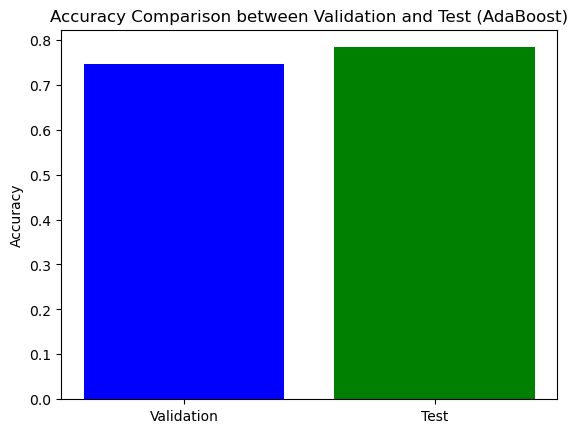

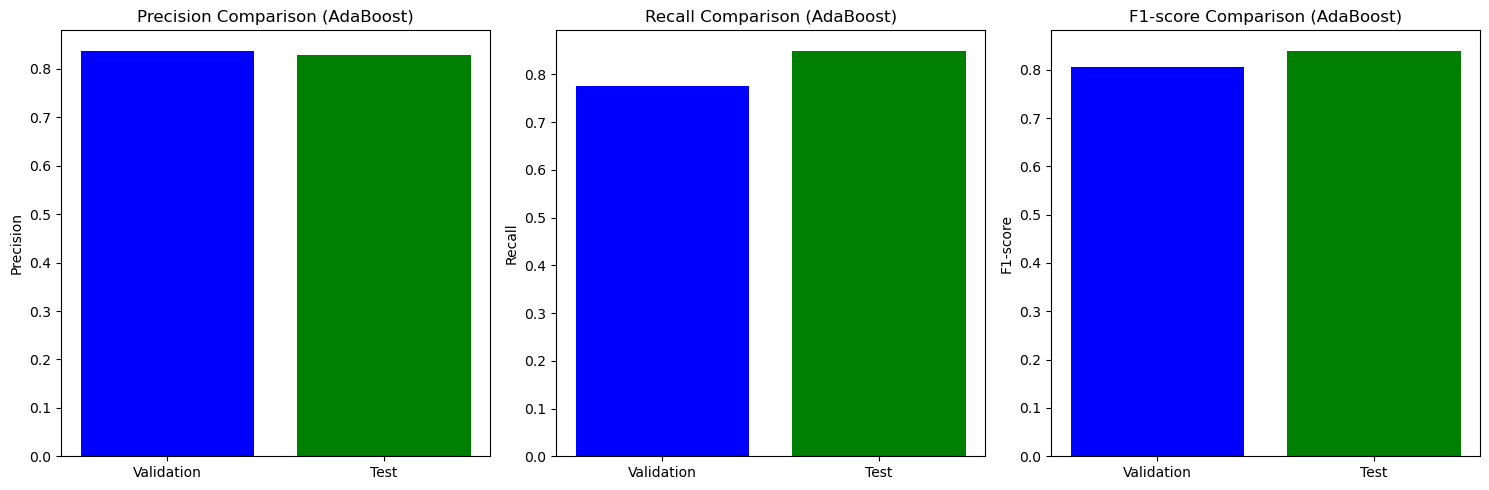

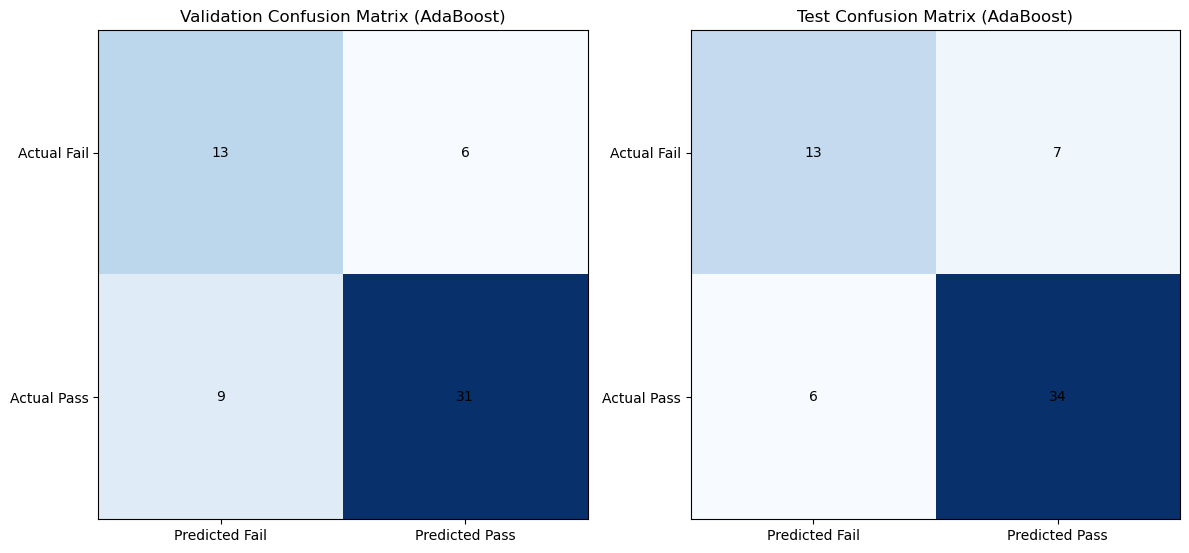

In [146]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Initialize AdaBoost Classifier with default settings
ab_model = AdaBoostClassifier(random_state=42)

# Train the model on the balanced, scaled training data
ab_model.fit(X_train_scaled, y_train_bal)

# Predictions on validation and test sets
y_val_pred_ab = ab_model.predict(X_val_scaled)
y_test_pred_ab = ab_model.predict(X_test_scaled)

# Classification metrics for the tuned model
val_report_ab = classification_report(y_val, y_val_pred_ab, output_dict=True)
test_report_ab = classification_report(y_test, y_test_pred_ab, output_dict=True)

# Accuracy comparison
val_accuracy_ab = accuracy_score(y_val, y_val_pred_ab)
test_accuracy_ab = accuracy_score(y_test, y_test_pred_ab)

# Print Classification Report for Validation Set
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_ab))

# Print Classification Report for Test Set
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_ab))

# Print Accuracy Comparison
print("\nAccuracy Comparison:")
print(f"Validation Accuracy: {val_accuracy_ab:.4f}")
print(f"Test Accuracy: {test_accuracy_ab:.4f}")

# Plotting accuracy comparison between validation and test sets
fig, ax = plt.subplots()
ax.bar(['Validation', 'Test'], [val_accuracy_ab, test_accuracy_ab], color=['blue', 'green'])
ax.set_title('Accuracy Comparison between Validation and Test (AdaBoost)')
ax.set_ylabel('Accuracy')
plt.show()

# Plotting other metrics comparison after tuning: precision, recall, and F1-score
metrics_values_ab = {metric: [val_report_ab['1'][metric], test_report_ab['1'][metric]] for metric in ['precision', 'recall', 'f1-score']}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(['precision', 'recall', 'f1-score']):
    ax[i].bar(['Validation', 'Test'], metrics_values_ab[metric], color=['blue', 'green'])
    ax[i].set_title(f'{metric.capitalize()} Comparison (AdaBoost)')
    ax[i].set_ylabel(metric.capitalize())
plt.tight_layout()
plt.show()

# Plotting confusion matrix for the AdaBoost model with annotations
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# For Validation Confusion Matrix
val_conf_matrix_ab = confusion_matrix(y_val, y_val_pred_ab)
ax[0].imshow(val_conf_matrix_ab, cmap='Blues', interpolation='nearest')
ax[0].set_title('Validation Confusion Matrix (AdaBoost)')
for i in range(val_conf_matrix_ab.shape[0]):
    for j in range(val_conf_matrix_ab.shape[1]):
        ax[0].text(j, i, str(val_conf_matrix_ab[i, j]), ha='center', va='center', color='black')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[0].set_yticklabels(['Actual Fail', 'Actual Pass'])

# For Test Confusion Matrix
test_conf_matrix_ab = confusion_matrix(y_test, y_test_pred_ab)
ax[1].imshow(test_conf_matrix_ab, cmap='Blues', interpolation='nearest')
ax[1].set_title('Test Confusion Matrix (AdaBoost)')
for i in range(test_conf_matrix_ab.shape[0]):
    for j in range(test_conf_matrix_ab.shape[1]):
        ax[1].text(j, i, str(test_conf_matrix_ab[i, j]), ha='center', va='center', color='black')
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[1].set_yticklabels(['Actual Fail', 'Actual Pass'])

plt.tight_layout()
plt.show()


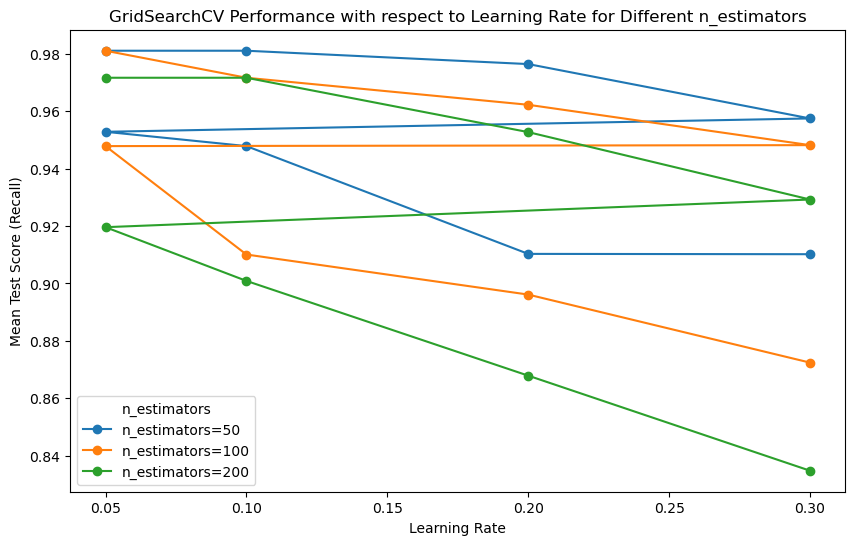

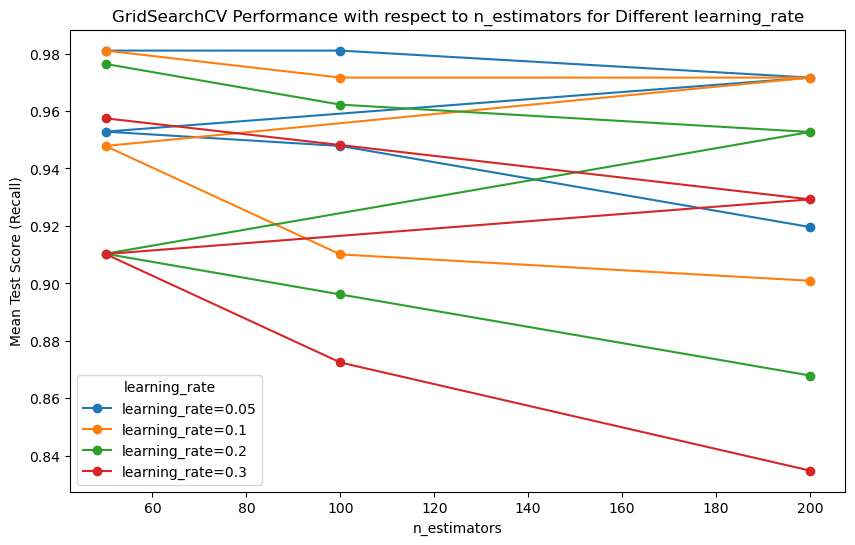

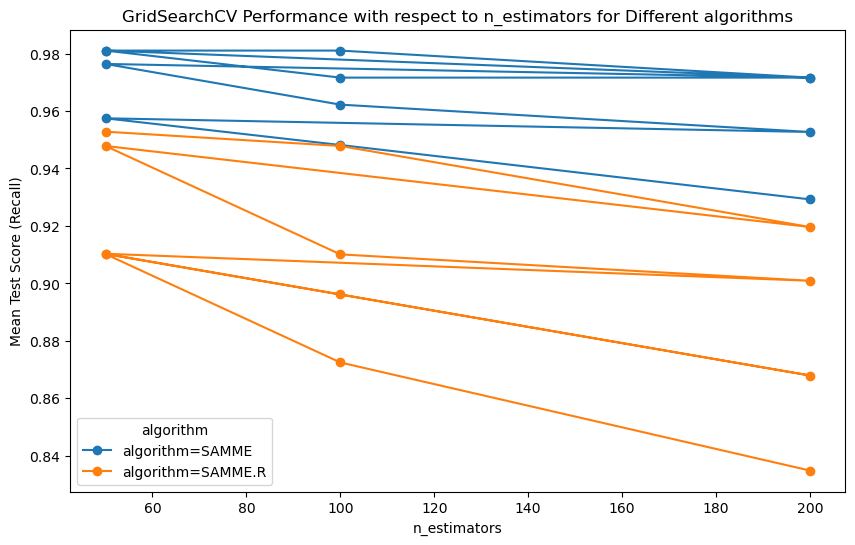

Best Parameters for AdaBoost: {'algorithm': 'SAMME', 'learning_rate': 0.05, 'n_estimators': 50}


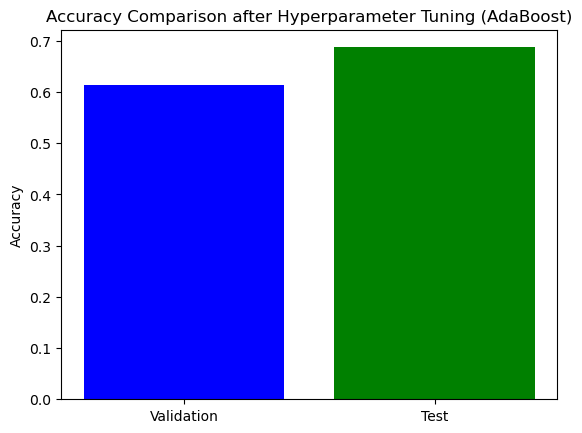

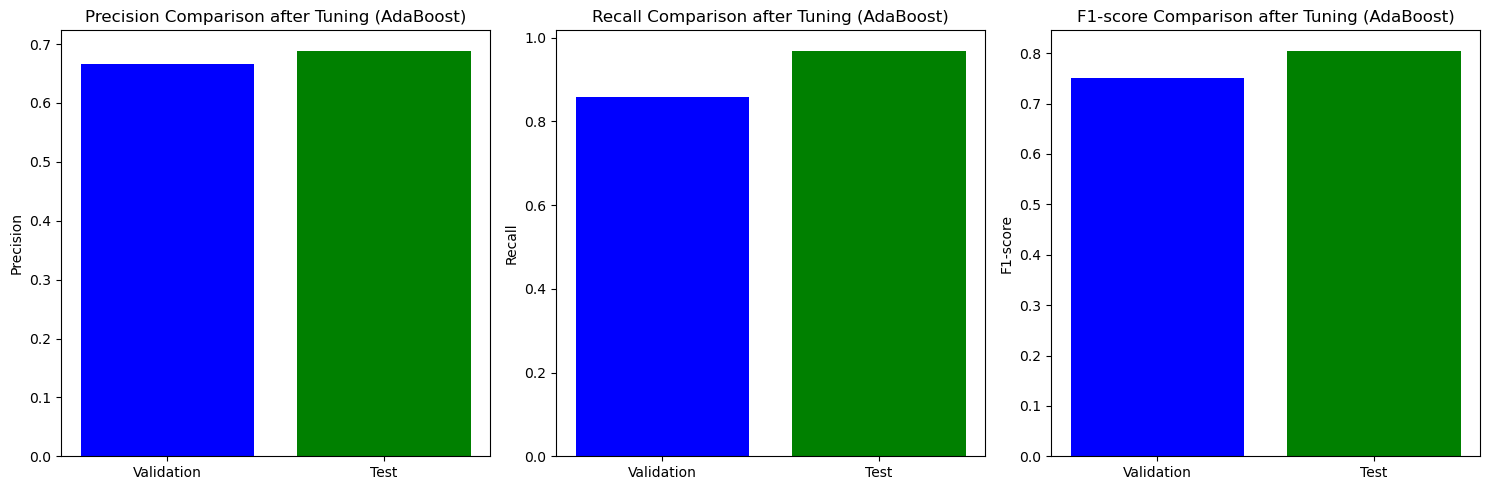

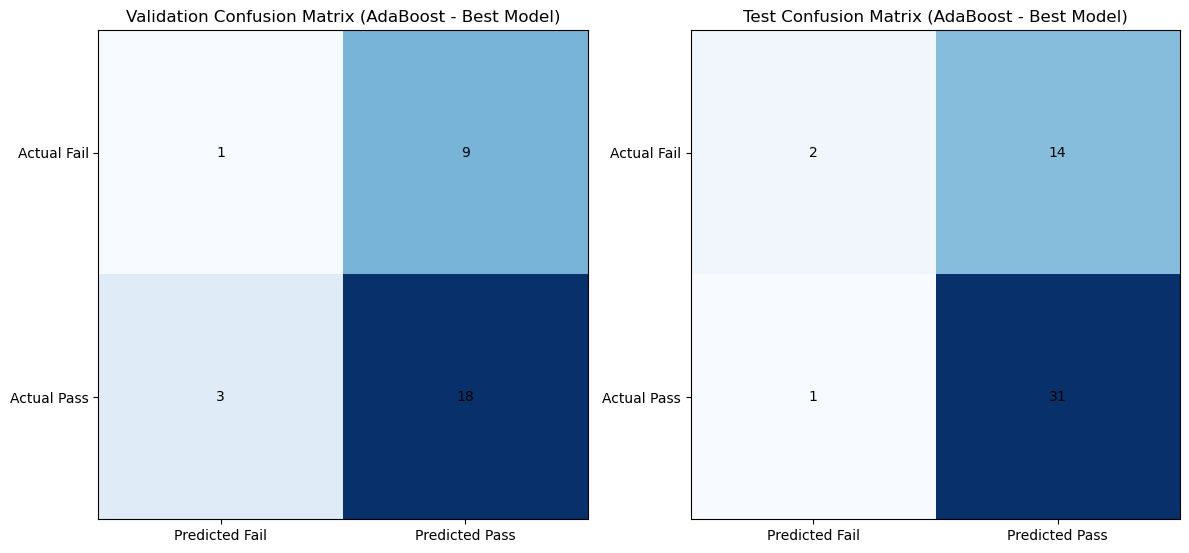

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

# Initialize AdaBoost Classifier with default settings
ab_model = AdaBoostClassifier(random_state=42)

# Define parameter grid for hyperparameter tuning
param_grid_ab = {
    'n_estimators': [50, 100, 200],             # Number of base learners (weak models)
    'learning_rate': [0.05, 0.1, 0.2, 0.3],     # Step size at each iteration
    'algorithm': ['SAMME', 'SAMME.R']            # SAMME.R generally performs better
}

# Initialize GridSearchCV with 5-fold cross-validation and recall as scoring metric
grid_search_ab = GridSearchCV(estimator=ab_model, param_grid=param_grid_ab, cv=5, n_jobs=-1, scoring='recall')

# Fit GridSearchCV to the training data
grid_search_ab.fit(X_train_scaled, y_train_bal)

# Get the grid search results as a DataFrame
results_ab = pd.DataFrame(grid_search_ab.cv_results_)

# Plot for n_estimators vs mean_test_score
plt.figure(figsize=(10, 6))
for n_estimators in results_ab['param_n_estimators'].unique():
    subset = results_ab[results_ab['param_n_estimators'] == n_estimators]
    plt.plot(subset['param_learning_rate'], subset['mean_test_score'], label=f'n_estimators={n_estimators}', marker='o')
plt.title('GridSearchCV Performance with respect to Learning Rate for Different n_estimators')
plt.xlabel('Learning Rate')
plt.ylabel('Mean Test Score (Recall)')
plt.legend(title='n_estimators')
plt.show()

# Plot for learning_rate vs mean_test_score
plt.figure(figsize=(10, 6))
for learning_rate in results_ab['param_learning_rate'].unique():
    subset = results_ab[results_ab['param_learning_rate'] == learning_rate]
    plt.plot(subset['param_n_estimators'], subset['mean_test_score'], label=f'learning_rate={learning_rate}', marker='o')
plt.title('GridSearchCV Performance with respect to n_estimators for Different learning_rate')
plt.xlabel('n_estimators')
plt.ylabel('Mean Test Score (Recall)')
plt.legend(title='learning_rate')
plt.show()

# Plot for algorithm vs mean_test_score
plt.figure(figsize=(10, 6))
for algorithm in results_ab['param_algorithm'].unique():
    subset = results_ab[results_ab['param_algorithm'] == algorithm]
    plt.plot(subset['param_n_estimators'], subset['mean_test_score'], label=f'algorithm={algorithm}', marker='o')
plt.title('GridSearchCV Performance with respect to n_estimators for Different algorithms')
plt.xlabel('n_estimators')
plt.ylabel('Mean Test Score (Recall)')
plt.legend(title='algorithm')
plt.show()

# Best parameters from grid search
best_params_ab = grid_search_ab.best_params_
print("Best Parameters for AdaBoost:", best_params_ab)

# Best model from grid search
best_ab_model = grid_search_ab.best_estimator_

# Predictions on validation and test sets with best model
y_val_pred_ab_best = best_ab_model.predict(X_val_scaled)
y_test_pred_ab_best = best_ab_model.predict(X_test_scaled)

# Classification metrics for the tuned model
val_report_ab_best = classification_report(y_val, y_val_pred_ab_best, output_dict=True)
test_report_ab_best = classification_report(y_test, y_test_pred_ab_best, output_dict=True)

# Accuracy comparison after hyperparameter tuning
val_accuracy_ab_best = accuracy_score(y_val, y_val_pred_ab_best)
test_accuracy_ab_best = accuracy_score(y_test, y_test_pred_ab_best)

# Plotting accuracy comparison after hyperparameter tuning
fig, ax = plt.subplots()
ax.bar(['Validation', 'Test'], [val_accuracy_ab_best, test_accuracy_ab_best], color=['blue', 'green'])
ax.set_title('Accuracy Comparison after Hyperparameter Tuning (AdaBoost)')
ax.set_ylabel('Accuracy')
plt.show()

# Plotting other metrics comparison after tuning: precision, recall, and F1-score
metrics_values_ab_best = {metric: [val_report_ab_best['1'][metric], test_report_ab_best['1'][metric]] for metric in ['precision', 'recall', 'f1-score']}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(['precision', 'recall', 'f1-score']):
    ax[i].bar(['Validation', 'Test'], metrics_values_ab_best[metric], color=['blue', 'green'])
    ax[i].set_title(f'{metric.capitalize()} Comparison after Tuning (AdaBoost)')
    ax[i].set_ylabel(metric.capitalize())
plt.tight_layout()
plt.show()

# Plotting confusion matrix for the best model with annotations in black font
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# For Validation Confusion Matrix
val_conf_matrix_ab_best = confusion_matrix(y_val, y_val_pred_ab_best)
ax[0].imshow(val_conf_matrix_ab_best, cmap='Blues', interpolation='nearest')
ax[0].set_title('Validation Confusion Matrix (AdaBoost - Best Model)')
for i in range(val_conf_matrix_ab_best.shape[0]):
    for j in range(val_conf_matrix_ab_best.shape[1]):
        ax[0].text(j, i, str(val_conf_matrix_ab_best[i, j]), ha='center', va='center', color='black')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[0].set_yticklabels(['Actual Fail', 'Actual Pass'])

# For Test Confusion Matrix
test_conf_matrix_ab_best = confusion_matrix(y_test, y_test_pred_ab_best)
ax[1].imshow(test_conf_matrix_ab_best, cmap='Blues', interpolation='nearest')
ax[1].set_title('Test Confusion Matrix (AdaBoost - Best Model)')
for i in range(test_conf_matrix_ab_best.shape[0]):
    for j in range(test_conf_matrix_ab_best.shape[1]):
        ax[1].text(j, i, str(test_conf_matrix_ab_best[i, j]), ha='center', va='center', color='black')
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[1].set_yticklabels(['Actual Fail', 'Actual Pass'])

plt.tight_layout()
plt.show()


Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.64      0.95      0.77        19
           1       0.97      0.75      0.85        40

    accuracy                           0.81        59
   macro avg       0.81      0.85      0.81        59
weighted avg       0.86      0.81      0.82        59


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.61      1.00      0.75        20
           1       1.00      0.68      0.81        40

    accuracy                           0.78        60
   macro avg       0.80      0.84      0.78        60
weighted avg       0.87      0.78      0.79        60


Accuracy Comparison:
Validation Accuracy: 0.8136
Test Accuracy: 0.7833


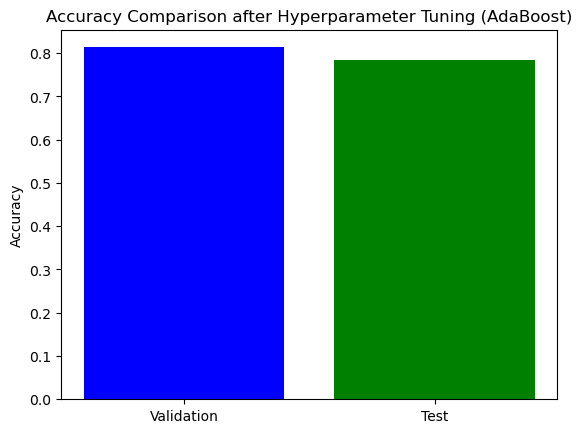

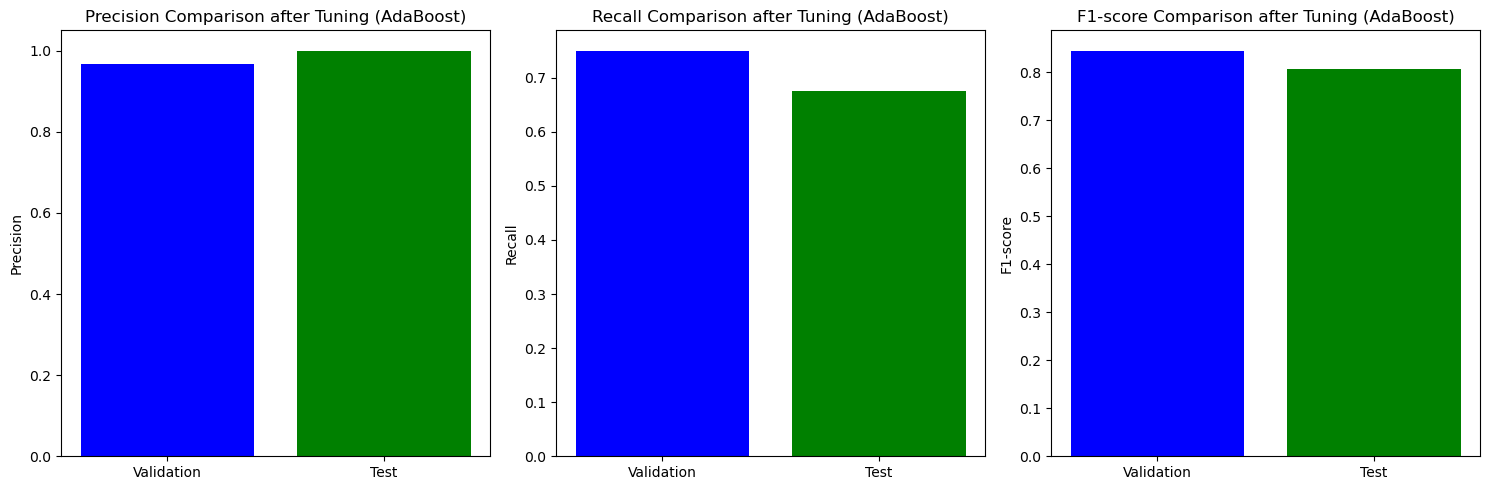

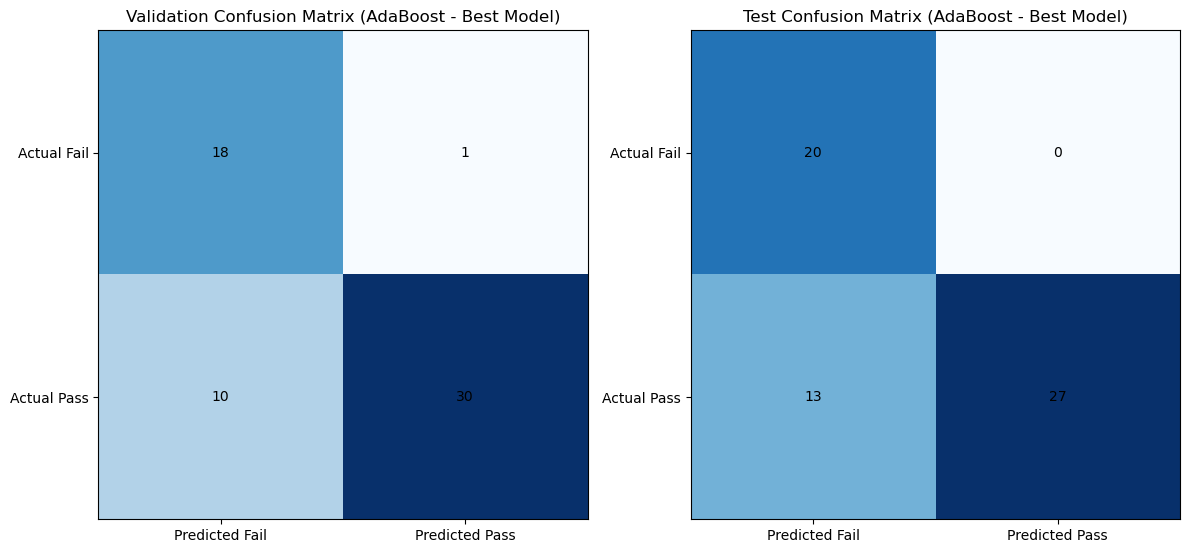

In [162]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

# Best Parameters for AdaBoost
best_ab_params = {
    'algorithm': 'SAMME',
    'learning_rate': 0.0005,
    'n_estimators': 2000,
}

# Initialize AdaBoost Classifier with the best hyperparameters
best_ab_model = AdaBoostClassifier(**best_ab_params)

# Train the model on the balanced, scaled training data
best_ab_model.fit(X_train_scaled, y_train_bal)

# Predictions on validation and test sets with the best model
y_val_pred_ab_best = best_ab_model.predict(X_val_scaled)
y_test_pred_ab_best = best_ab_model.predict(X_test_scaled)

# Classification metrics for the tuned model
val_report_ab_best = classification_report(y_val, y_val_pred_ab_best, output_dict=True)
test_report_ab_best = classification_report(y_test, y_test_pred_ab_best, output_dict=True)

# Accuracy comparison after hyperparameter tuning
val_accuracy_ab_best = accuracy_score(y_val, y_val_pred_ab_best)
test_accuracy_ab_best = accuracy_score(y_test, y_test_pred_ab_best)

# Print Classification Report for Validation Set
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_ab_best))

# Print Classification Report for Test Set
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_ab_best))

# Print Accuracy Comparison
print("\nAccuracy Comparison:")
print(f"Validation Accuracy: {val_accuracy_ab_best:.4f}")
print(f"Test Accuracy: {test_accuracy_ab_best:.4f}")

# Plotting accuracy comparison after hyperparameter tuning
fig, ax = plt.subplots()
ax.bar(['Validation', 'Test'], [val_accuracy_ab_best, test_accuracy_ab_best], color=['blue', 'green'])
ax.set_title('Accuracy Comparison after Hyperparameter Tuning (AdaBoost)')
ax.set_ylabel('Accuracy')
plt.show()

# Plotting other metrics comparison after tuning: precision, recall, and F1-score
metrics_values_ab_best = {metric: [val_report_ab_best['1'][metric], test_report_ab_best['1'][metric]] for metric in ['precision', 'recall', 'f1-score']}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(['precision', 'recall', 'f1-score']):
    ax[i].bar(['Validation', 'Test'], metrics_values_ab_best[metric], color=['blue', 'green'])
    ax[i].set_title(f'{metric.capitalize()} Comparison after Tuning (AdaBoost)')
    ax[i].set_ylabel(metric.capitalize())
plt.tight_layout()
plt.show()

# Plotting confusion matrix for the AdaBoost model with annotations
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# For Validation Confusion Matrix
val_conf_matrix_ab_best = confusion_matrix(y_val, y_val_pred_ab_best)
ax[0].imshow(val_conf_matrix_ab_best, cmap='Blues', interpolation='nearest')
ax[0].set_title('Validation Confusion Matrix (AdaBoost - Best Model)')
for i in range(val_conf_matrix_ab_best.shape[0]):
    for j in range(val_conf_matrix_ab_best.shape[1]):
        ax[0].text(j, i, str(val_conf_matrix_ab_best[i, j]), ha='center', va='center', color='black')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[0].set_yticklabels(['Actual Fail', 'Actual Pass'])

# For Test Confusion Matrix
test_conf_matrix_ab_best = confusion_matrix(y_test, y_test_pred_ab_best)
ax[1].imshow(test_conf_matrix_ab_best, cmap='Blues', interpolation='nearest')
ax[1].set_title('Test Confusion Matrix (AdaBoost - Best Model)')
for i in range(test_conf_matrix_ab_best.shape[0]):
    for j in range(test_conf_matrix_ab_best.shape[1]):
        ax[1].text(j, i, str(test_conf_matrix_ab_best[i, j]), ha='center', va='center', color='black')
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[1].set_yticklabels(['Actual Fail', 'Actual Pass'])

plt.tight_layout()
plt.show()


In [ ]:
#VOTING CLASSIFIER

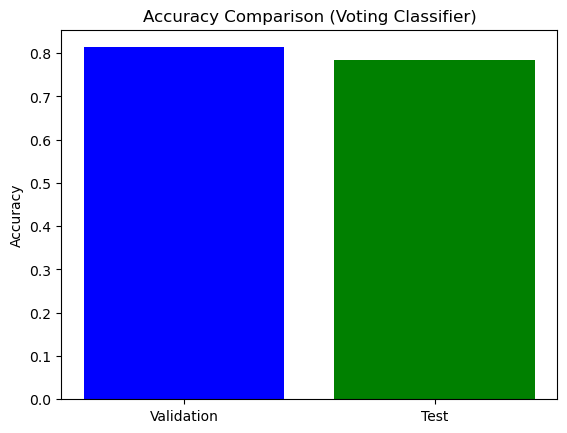

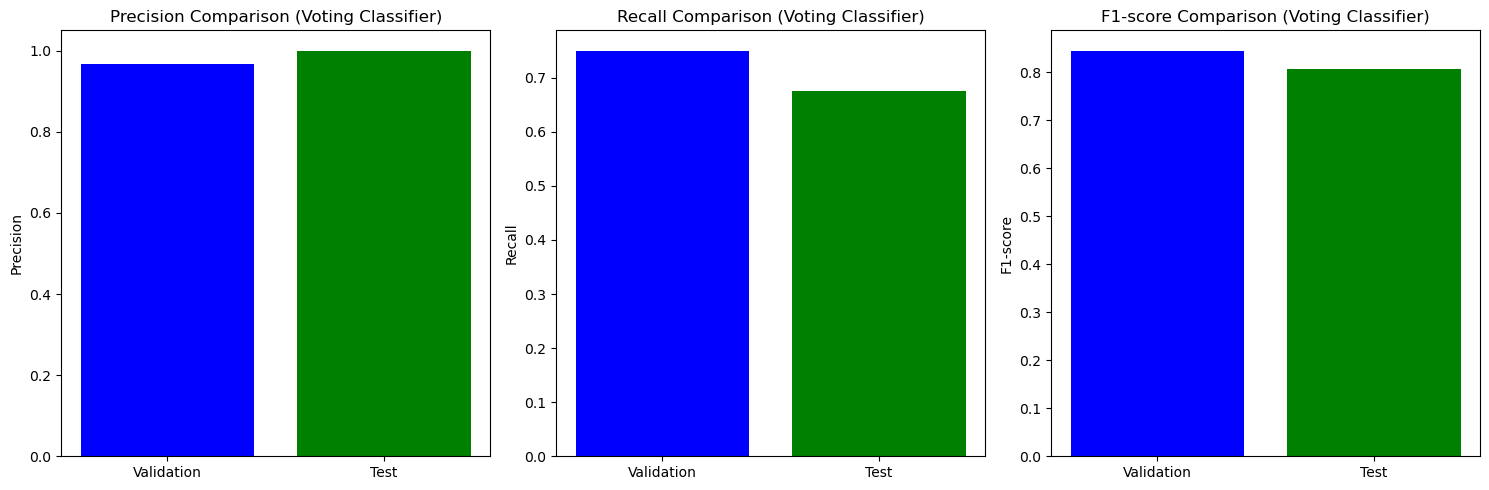

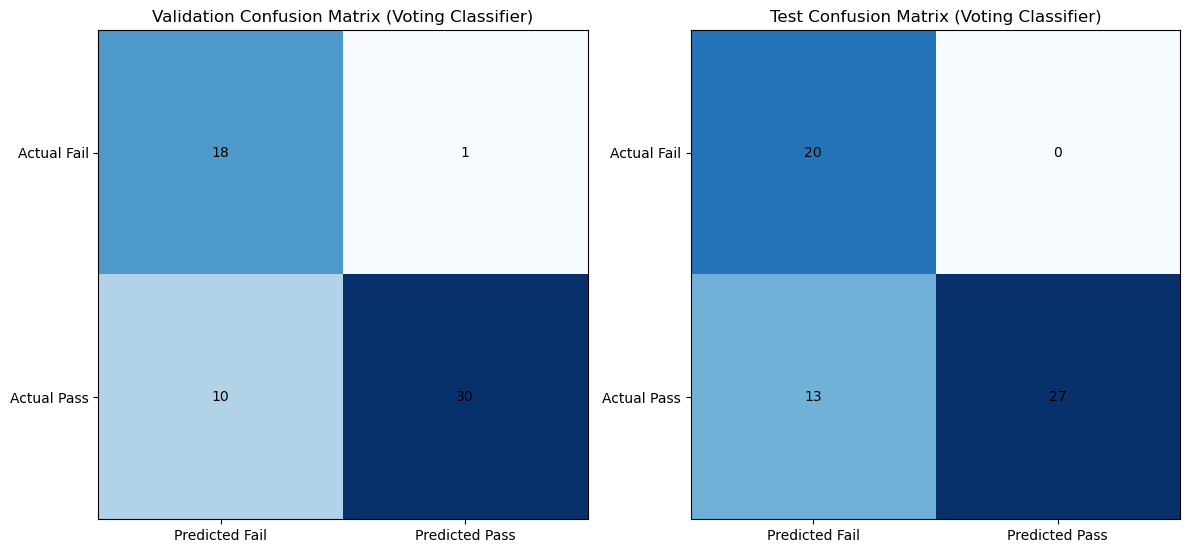

      Metric  Validation      Test
0   Accuracy    0.813559  0.783333
1  Precision    0.967742  1.000000
2     Recall    0.750000  0.675000
3   F1-Score    0.845070  0.805970


In [148]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Initialize models with the best hyperparameters from previous steps
dt_best = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=3, 
    min_samples_leaf=1, 
    min_samples_split=2,
    random_state=42
)

rf_best = RandomForestClassifier(
    bootstrap=True,
    max_depth=10,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=50,
    random_state=42
)

gb_best = GradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=1,
    min_samples_split=10,
    n_estimators=50,
    random_state=42
)

ab_best = AdaBoostClassifier(
    algorithm='SAMME',
    learning_rate=0.05,
    n_estimators=50,
    random_state=42
)

# Create the Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('dt', dt_best),
        ('rf', rf_best),
        ('gb', gb_best),
        ('ab', ab_best)
    ], voting='hard'  # 'hard' for majority class voting (or 'soft' for probability-based)
)

# Train the Voting Classifier on the balanced, scaled training data
voting_clf.fit(X_train_scaled, y_train_bal)

# Predictions on validation and test sets with the Voting Classifier
y_val_pred_vc = voting_clf.predict(X_val_scaled)
y_test_pred_vc = voting_clf.predict(X_test_scaled)

# Classification metrics for the Voting Classifier
val_report_vc = classification_report(y_val, y_val_pred_vc, output_dict=True)
test_report_vc = classification_report(y_test, y_test_pred_vc, output_dict=True)

# Accuracy comparison after using the Voting Classifier
val_accuracy_vc = accuracy_score(y_val, y_val_pred_vc)
test_accuracy_vc = accuracy_score(y_test, y_test_pred_vc)

# Plotting accuracy comparison after using the Voting Classifier
fig, ax = plt.subplots()
ax.bar(['Validation', 'Test'], [val_accuracy_vc, test_accuracy_vc], color=['blue', 'green'])
ax.set_title('Accuracy Comparison (Voting Classifier)')
ax.set_ylabel('Accuracy')
plt.show()

# Plotting other metrics comparison after using the Voting Classifier: precision, recall, and F1-score
metrics_values_vc = {metric: [val_report_vc['1'][metric], test_report_vc['1'][metric]] for metric in ['precision', 'recall', 'f1-score']}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(['precision', 'recall', 'f1-score']):
    ax[i].bar(['Validation', 'Test'], metrics_values_vc[metric], color=['blue', 'green'])
    ax[i].set_title(f'{metric.capitalize()} Comparison (Voting Classifier)')
    ax[i].set_ylabel(metric.capitalize())
plt.tight_layout()
plt.show()

# Plotting confusion matrix for the Voting Classifier
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# For Validation Confusion Matrix
val_conf_matrix_vc = confusion_matrix(y_val, y_val_pred_vc)
ax[0].imshow(val_conf_matrix_vc, cmap='Blues', interpolation='nearest')
ax[0].set_title('Validation Confusion Matrix (Voting Classifier)')
for i in range(val_conf_matrix_vc.shape[0]):
    for j in range(val_conf_matrix_vc.shape[1]):
        ax[0].text(j, i, str(val_conf_matrix_vc[i, j]), ha='center', va='center', color='black')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[0].set_yticklabels(['Actual Fail', 'Actual Pass'])

# For Test Confusion Matrix
test_conf_matrix_vc = confusion_matrix(y_test, y_test_pred_vc)
ax[1].imshow(test_conf_matrix_vc, cmap='Blues', interpolation='nearest')
ax[1].set_title('Test Confusion Matrix (Voting Classifier)')
for i in range(test_conf_matrix_vc.shape[0]):
    for j in range(test_conf_matrix_vc.shape[1]):
        ax[1].text(j, i, str(test_conf_matrix_vc[i, j]), ha='center', va='center', color='black')
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[1].set_yticklabels(['Actual Fail', 'Actual Pass'])

plt.tight_layout()
plt.show()

# Table of metrics (Accuracy, Precision, Recall, F1-Score)
metrics_table_vc = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Validation': [
        val_accuracy_vc,
        val_report_vc['1']['precision'],
        val_report_vc['1']['recall'],
        val_report_vc['1']['f1-score']
    ],
    'Test': [
        test_accuracy_vc,
        test_report_vc['1']['precision'],
        test_report_vc['1']['recall'],
        test_report_vc['1']['f1-score']
    ]
}

# Convert to DataFrame for better readability
metrics_df_vc = pd.DataFrame(metrics_table_vc)

# Display the table
print(metrics_df_vc)


In [ ]:
#FINAL REPORT